# SARIMAX Modeling with Statespace

:::{attention}
This notebook uses libraries that are not PyMC dependencies
and therefore need to be installed specifically to run this notebook.
Open the dropdown below for extra guidance.
:::

::::::{dropdown} Extra dependencies install instructions
:icon: package-dependencies
In order to run this notebook (either locally or on binder) you won't only
need a working PyMC installation with all optional dependencies,
but also to install some extra dependencies.
For advise on installing PyMC itself, please refer to {ref}`pymc:installation`

You can install these dependencies with your preferred package manager, we provide
as an example the pip and conda commands below.

> $ pip install statsmodels nutpie

Note that if you want (or need) to install the packages from inside the notebook instead
of the command line, you can install
the packages by running a variation of the pip command:

> import sys
>
> !{sys.executable} -m pip install statsmodels nutpie

You should not run `!pip install` as it might install the package in a different
environment and not be available from the Jupyter notebook even if installed.

Another alternative is using conda instead:

> $ conda install statsmodels nutpie

when installing scientific python packages with conda,
we recommend using [conda forge](https://conda-forge.org/index.html)
::::::

In [1]:
%matplotlib inline


import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import statsmodels.api as sm

from pymc.model.transform.optimization import freeze_dims_and_data
from pytensor import tensor as pt

import pymc_extras.statespace as pmss

warnings.filterwarnings(action="ignore", message="The RandomType SharedVariables")


config = {
    "figure.figsize": [12.0, 4.0],
    "figure.dpi": 72.0 * 2,
    "figure.facecolor": "w",
    "figure.constrained_layout.use": True,
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.bottom": False,
    "axes.spines.left": False,
    "axes.spines.right": False,
}

plt.rcParams.update(config)


def sample_kwargs():
    return {
        "nuts_sampler": "nutpie",
        "cores": 8,
        "draws": 500,
        "tune": 1000,
    }

## Synthetic Data - ARMA(1,1)

Start very simple, so that stationarity at higher orders of p and q isn't a concern.

In [2]:
seed = sum(map(ord, "statespace arima"))
rng = np.random.default_rng(seed)

AR_params = [0.8, 0.0]
MA_params = [-0.5]
innovation_variance = 0.8

In [3]:
# Initial state
x0 = np.zeros(2)

# Hidden state transition matrix
T = np.array([[AR_params[0], 1.0], [AR_params[1], 0.0]])

# Hidden state noise coefficients
R = np.array([[1.0], [MA_params[0]]])

# Hidden state covariance matrix
Q = np.array([[innovation_variance]])

# Observation matrix
Z = np.array([[1.0, 0.0]])

# Observation noise covariance
H = np.array([[0.0]])

In [4]:
timesteps = 100
data = np.zeros(timesteps)
hidden_states = np.zeros((timesteps, 2))
hidden_states[0, :] = x0

innovations = rng.multivariate_normal(mean=np.array([0.0]), cov=Q, size=timesteps)

for t in range(1, timesteps):
    hidden_states[t] = T @ hidden_states[t - 1, :] + R @ np.atleast_1d(innovations[t])
    data[t] = (Z @ hidden_states[t]).item()

fake_dates = pd.date_range("2010-01-01", freq="MS", periods=data.shape[0])
df = pd.DataFrame(data, columns=["state"], index=fake_dates)

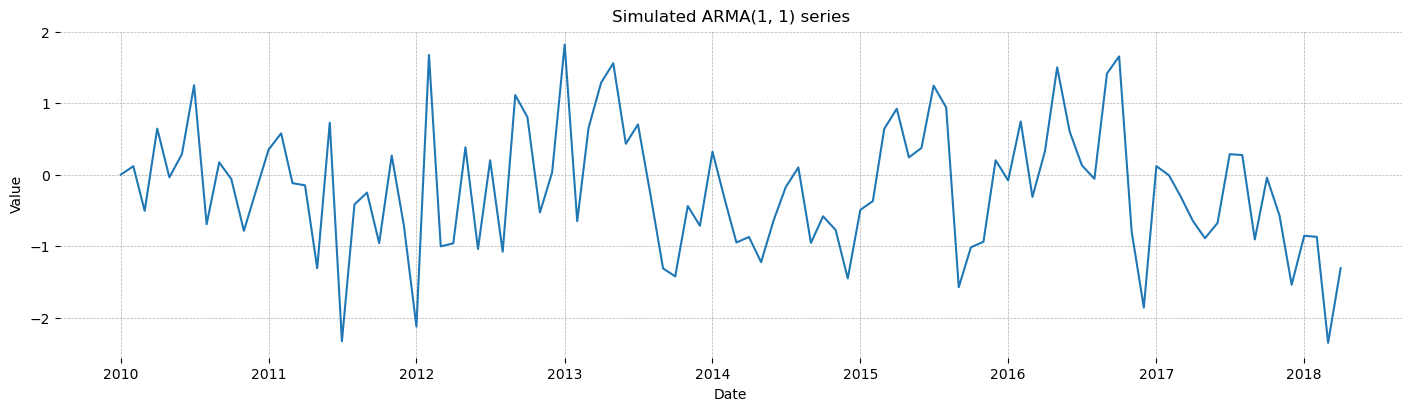

In [5]:
fig, ax = plt.subplots(figsize=(14, 4), dpi=100)
ax.plot(df.index, df["state"])
ax.set(title="Simulated ARMA(1, 1) series", xlabel="Date", ylabel="Value")
plt.show()

## Statsmodels

In [6]:
mod = sm.tsa.SARIMAX(endog=data, order=(1, 0, 1))
res = mod.fit(disp=0)
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  100
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -128.446
Date:                Mon, 24 Aug 2026   AIC                            262.892
Time:                        18:59:02   BIC                            270.708
Sample:                             0   HQIC                           266.055
                                - 100                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8077      0.174      4.632      0.000       0.466       1.150
ma.L1         -0.6162      0.231     -2.670      0.008      -1.069      -0.164
sigma2         0.7630      0.109      6.990      0.000       0.549       0.977
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.02
Prob(Q):                              0.84   Prob(JB):                         0.99
Heteroskedasticity (H):               0.97   Skew:                            -0.03
Prob(H) (two-sided):                  0.93   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## PyMC

Unlike the local level model, we don't need to explicitly estimate the initial state or covariance matrix for an ARIMA model, *if* the model dynamics are guaranteed to be stationary. Since we have an AR(1), that means the autoregressive parameter must be less than 1 in absolute value. In this case, closed form solutions for the steady state of the system can be used for the initial state:

$$x^\star = (I - T)^{-1}c$$

The covariance matrix is more complex, but can be obtained by solving this quadratic matrix equation (known as a "discrete Lyapunov equation"):

$$TP^{\star} T^T - P^{\star} + R Q R^T = 0$$

In [7]:
ss_mod = pmss.BayesianSARIMAX(order=(1, 0, 1), verbose=True)

                Model Requirements                 
                                                   
  Variable      Shape   Constraints    Dimensions  
 ───────────────────────────────────────────────── 
  ar_params     (1,)                  ('lag_ar',)  
  ma_params     (1,)                  ('lag_ma',)  
  sigma_state   ()      Positive             None  
                                                   
These parameters should be assigned priors inside a
        PyMC model block before calling the        
          build_statespace_graph method.           

In [8]:
ss_mod.coords

{'state': ('data', 'state_1'),
 'state_aux': ('data', 'state_1'),
 'observed_state': ('data',),
 'observed_state_aux': ('data',),
 'shock': ('innovation',),
 'shock_aux': ('innovation',),
 'lag_ar': (1,),
 'lag_ma': (1,)}

In [9]:
ss_mod.param_dims

{'ar_params': ('lag_ar',), 'ma_params': ('lag_ma',)}

In [10]:
with pm.Model(coords=ss_mod.coords) as arma_model:
    state_sigmas = pm.Gamma(
        "sigma_state", alpha=10, beta=2, dims=ss_mod.param_dims.get("sigma_state")
    )
    rho = pm.Beta("ar_params", alpha=5, beta=1, dims=ss_mod.param_dims.get("ar_params"))
    theta = pm.Normal("ma_params", mu=0.0, sigma=0.5, dims=ss_mod.param_dims.get("ma_params"))

    ss_mod.build_statespace_graph(df)

with freeze_dims_and_data(arma_model):
    prior = pm.sample_prior_predictive()

Sampling: [ar_params, ma_params, obs, sigma_state]


### Prior Predictive

#### Unconditional

A note about what the states are, first of all. For an ARMA (1,1) model, the state space transition equation is:

$$ \begin{bmatrix} y_{t+1} \\ x_{t+1} \end{bmatrix} =
    \begin{bmatrix}\rho & 1 \\ 0 & 0 \end{bmatrix} \begin{bmatrix} y_t \\ x_t \end{bmatrix} +
    \begin{bmatrix} 1 \\ \theta \end{bmatrix} \varepsilon_{t+1}
    $$

Which, if you work out the matrix multiplications, gives two state equations:

$$\begin{aligned} y_{t+1} &= \rho y_t + x_t + \varepsilon_{t+1} \\
    x_{t+1} &= \theta \varepsilon_{t+1} \end{aligned}$$

So the two states we end up with are the modeled data ($y_{t+1}$), and the innovation series, scaled by $\theta$. To recover the estimated innovations, you would need to divide the second state by $\theta$. It is also possible to write it such that the innovations are "carried along", but it doubles the number of states required. This is probably fine for small values of p and q, but bad for larger ones, since the Kalman filter needs to invert a matrix of size $k \times k$ each iteration.

We see two different types of trajectories in the priors. One is sharp and jagged, when $\rho$ and $\theta$ are large and negative. The other is smooth and meandering, when $\rho$ is positive and reasonable. When $\rho$ is very close to 1, we get the trajectories that wander out to +/- 20.

In [11]:
def plot_state_trajectories(draws, title):
    states = draws.coords["state"].values
    fig, axes = plt.subplots(len(states), 1, figsize=(14, 6), dpi=144, sharex=True)

    for axis, state in zip(axes, states):
        draws.sel(state=state).stack(sample=["chain", "draw"]).plot.line(
            x="time", ax=axis, add_legend=False
        )
        axis.set(title=state, xlabel="", ylabel="")

    axes[-1].set_xlabel("Date")
    fig.suptitle(title)

    return fig

In [12]:
unconditional_prior = ss_mod.sample_unconditional_prior(prior, progressbar=False)

Sampling: [prior_combined]


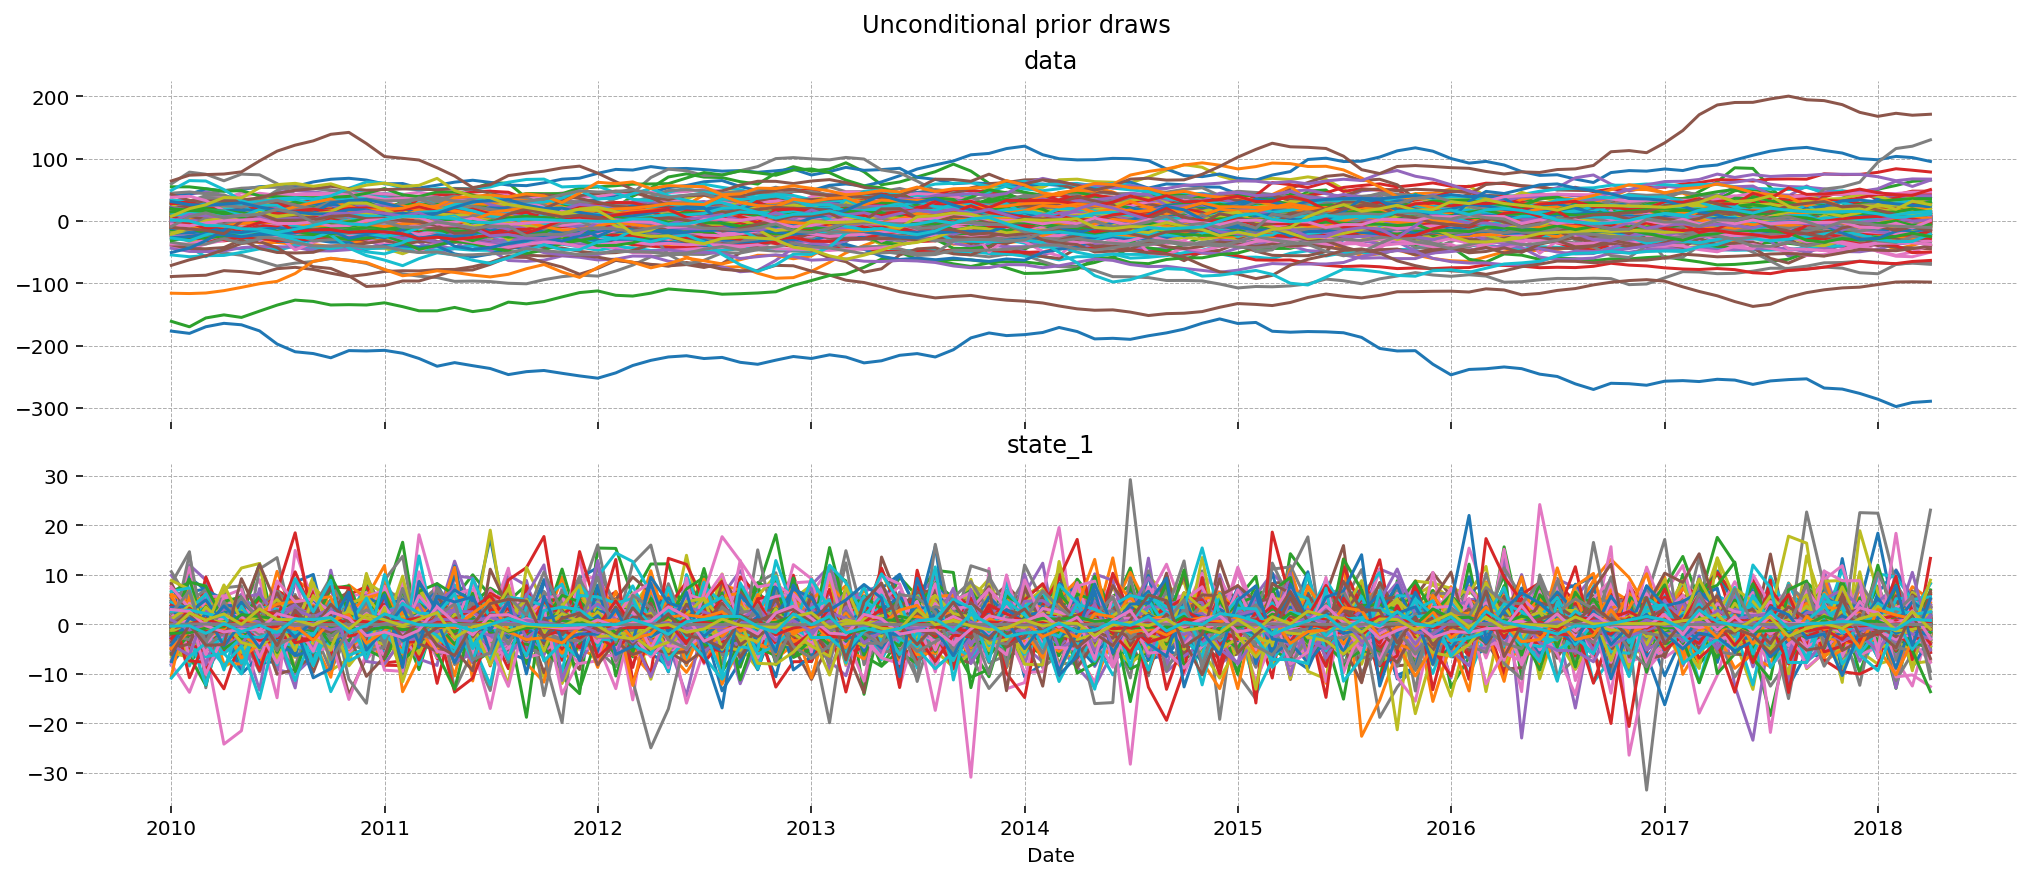

In [13]:
plot_state_trajectories(unconditional_prior.prior_latent, title="Unconditional prior draws")
plt.show()

#### Conditional

The conditional outputs for the Kalman smoother and filter aren't as interesting for this model, because the process noise doesn't have full rank. That is, only the second state, associated with the MA process, has noise added. The result is that the first state noiselessly encodes the data.

In [14]:
conditional_prior = ss_mod.sample_conditional_prior(prior)

Sampling: [filtered_prior, filtered_prior_observed, predicted_prior, predicted_prior_observed, smoothed_prior, smoothed_prior_observed]


Output()

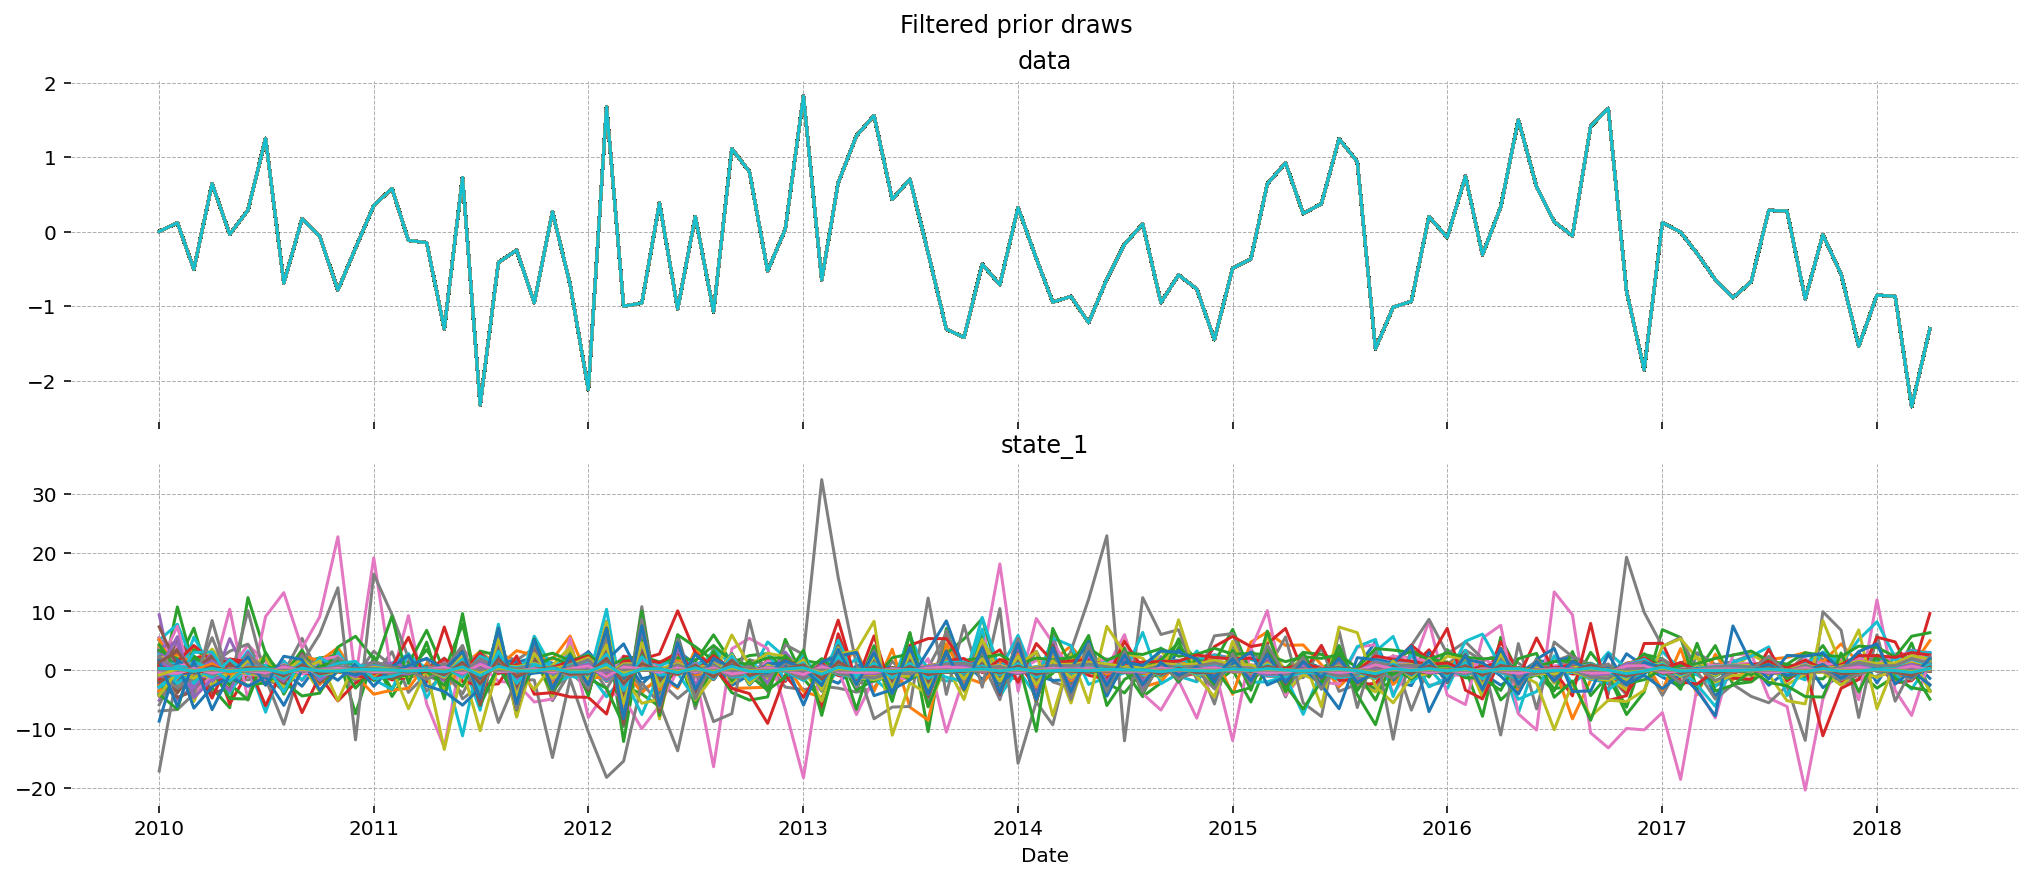

In [15]:
plot_state_trajectories(conditional_prior.filtered_prior, title="Filtered prior draws")
plt.show()

The Kalman predictions, $\mathbb E\left [ x_{t+1} | \{y_\tau\}_{\tau=0}^{t} \right]$, are a bit more interesting. `sample_conditional_prior` returns the filtered, predicted, and smoothed output together, so we just select the `predicted_prior` group.

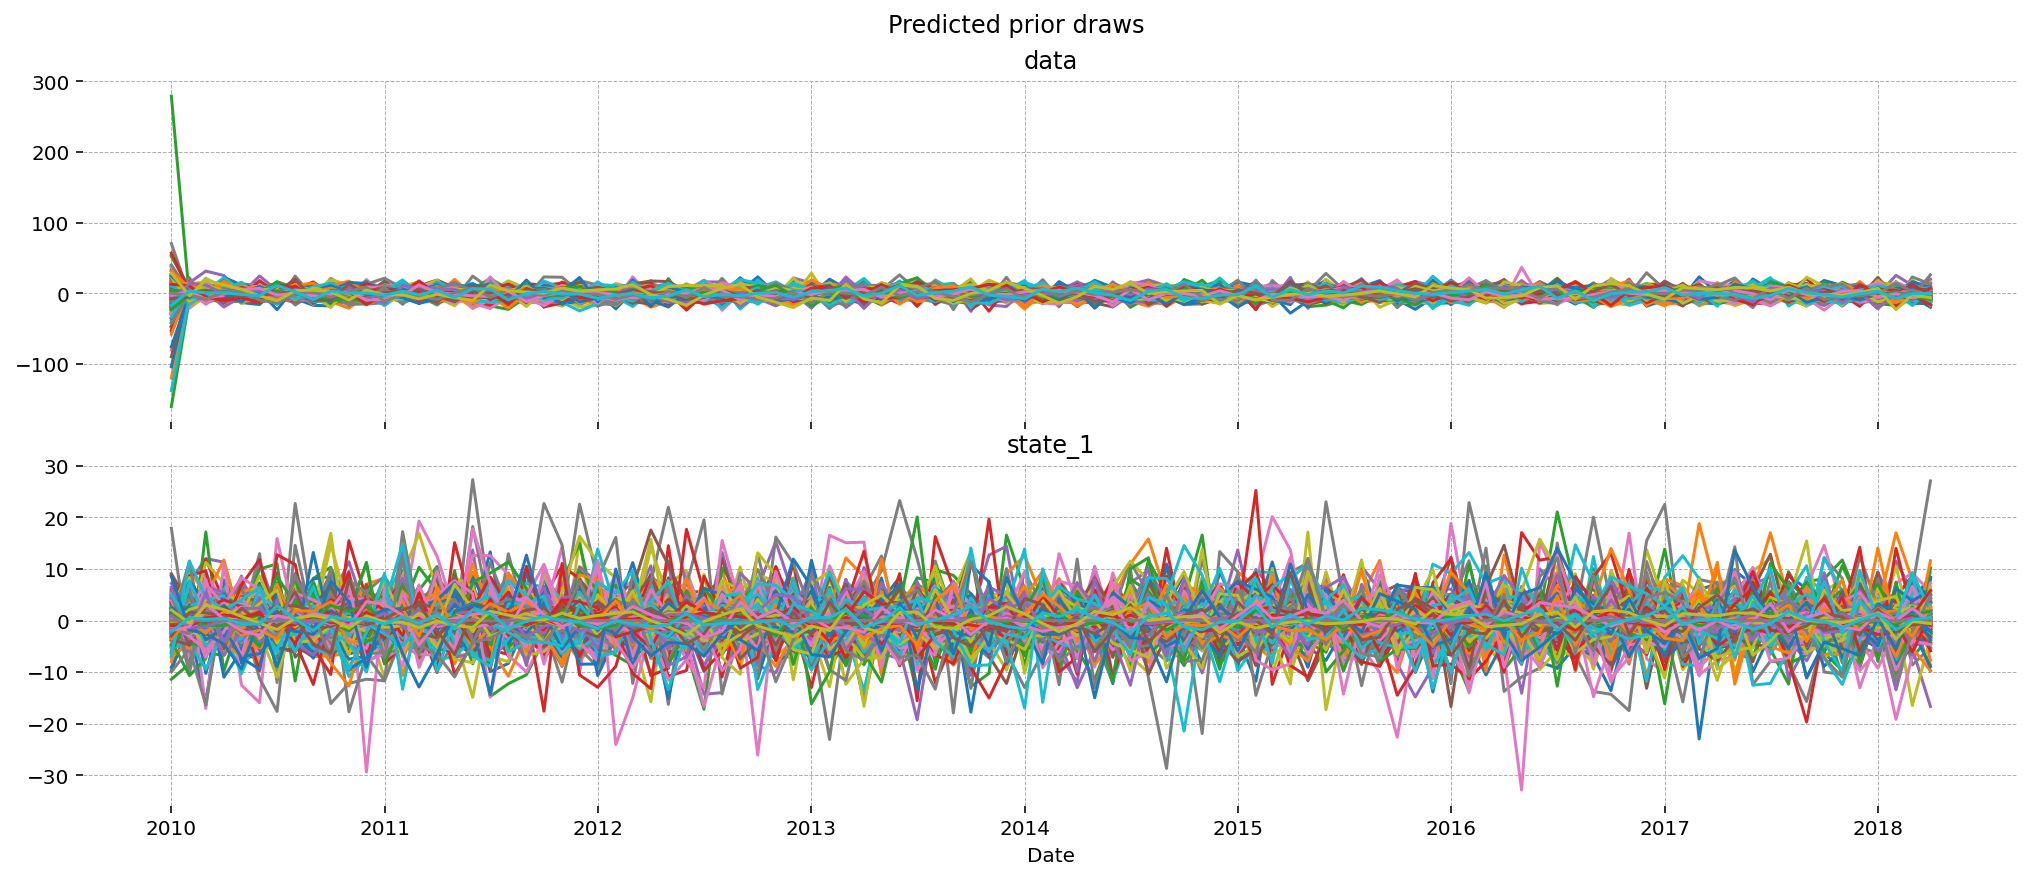

In [16]:
plot_state_trajectories(conditional_prior.predicted_prior, title="Predicted prior draws")
plt.show()

## Estimation

Finally on to actually fitting the model. There are ways to speed things up a bit. We are using stationary covariance initialization, which saves us from estimating the initial covariance matrix. PyMC Statespace also offers different flavors of Kalman Filter, some with some built in speedups (`steady_state`, but it's not JAX compatible).

For now we'll just go with the standard filter. There is a separate notebook explaining and comparing the different filtering choices.

In [17]:
with arma_model:
    idata = pm.sample(**sample_kwargs())

NUTS[nutpie]: [sigma_state, ar_params, ma_params]


Output()

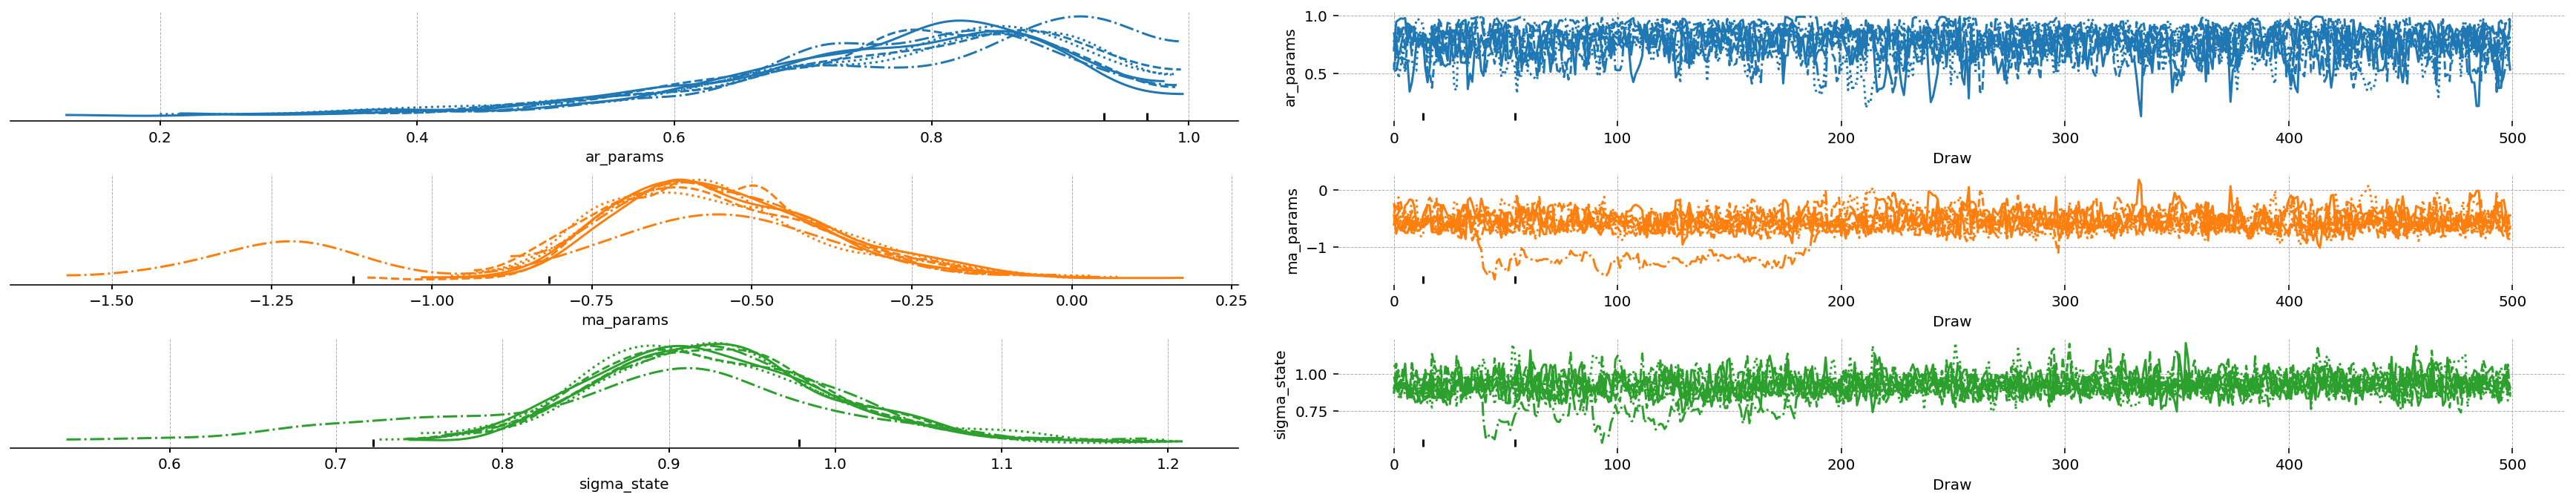

In [18]:
az.plot_trace_dist(idata, var_names=list(ss_mod.param_names));

Posterior estimates are reasonable, and the true value is contained in the 89% HDI in each case.

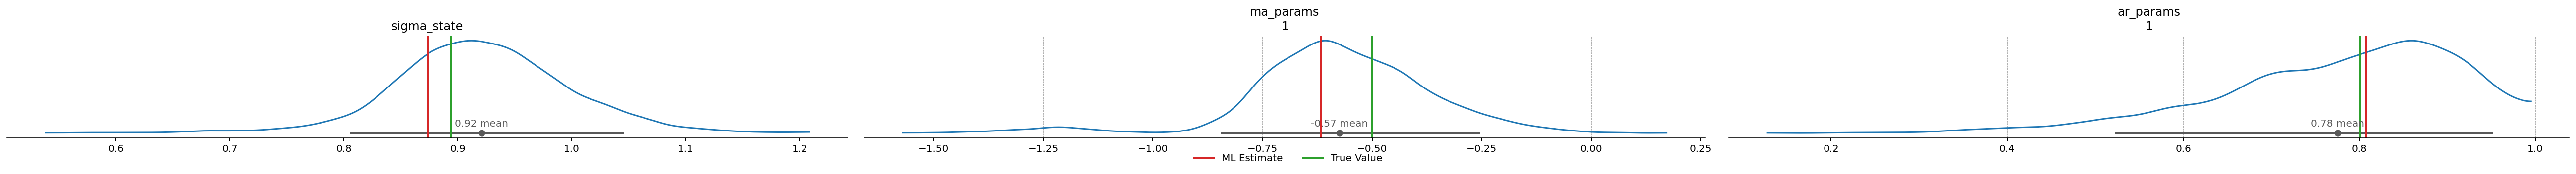

In [19]:
# Key by name rather than by position: statsmodels orders its parameters ar, ma, sigma2, which
# is not the order the panels are drawn in. sigma_state is a standard deviation, while both
# sigma2 and the simulation's innovation_variance are variances.
ml_by_name = dict(zip(res.param_names, res.params, strict=True))
ml_estimates = {
    "sigma_state": np.sqrt(ml_by_name["sigma2"]),
    "ma_params": ml_by_name["ma.L1"],
    "ar_params": ml_by_name["ar.L1"],
}
true_values = {
    "sigma_state": np.sqrt(innovation_variance),
    "ma_params": MA_params[0],
    "ar_params": AR_params[0],
}

pc = az.plot_dist(idata, var_names=list(ml_estimates))
for var in ml_estimates:
    target = pc.get_target(var, {})
    target.axvline(ml_estimates[var], color="tab:red", lw=2, label="ML Estimate")
    target.axvline(true_values[var], color="tab:green", lw=2, label="True Value")

handles, labels = target.get_legend_handles_labels()
target.get_figure().legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=2,
    frameon=False,
)
plt.show()

## Posterior Predictive

### Unconditional

In [20]:
unconditional_post = ss_mod.sample_unconditional_posterior(
    idata, steps=100, use_data_time_dim=False
)
unconditional_draws = az.extract(unconditional_post, "posterior_predictive")

Sampling: [posterior_combined]


Output()

Notice that no trajectories diverge away from the mean any more. The posterior rules out values of $\rho$ close to 1. Since we ended up with a stationary model, the long-term unconditional dynamics converge to a steady state mean and covariance matrix, which is what we are seeing here.

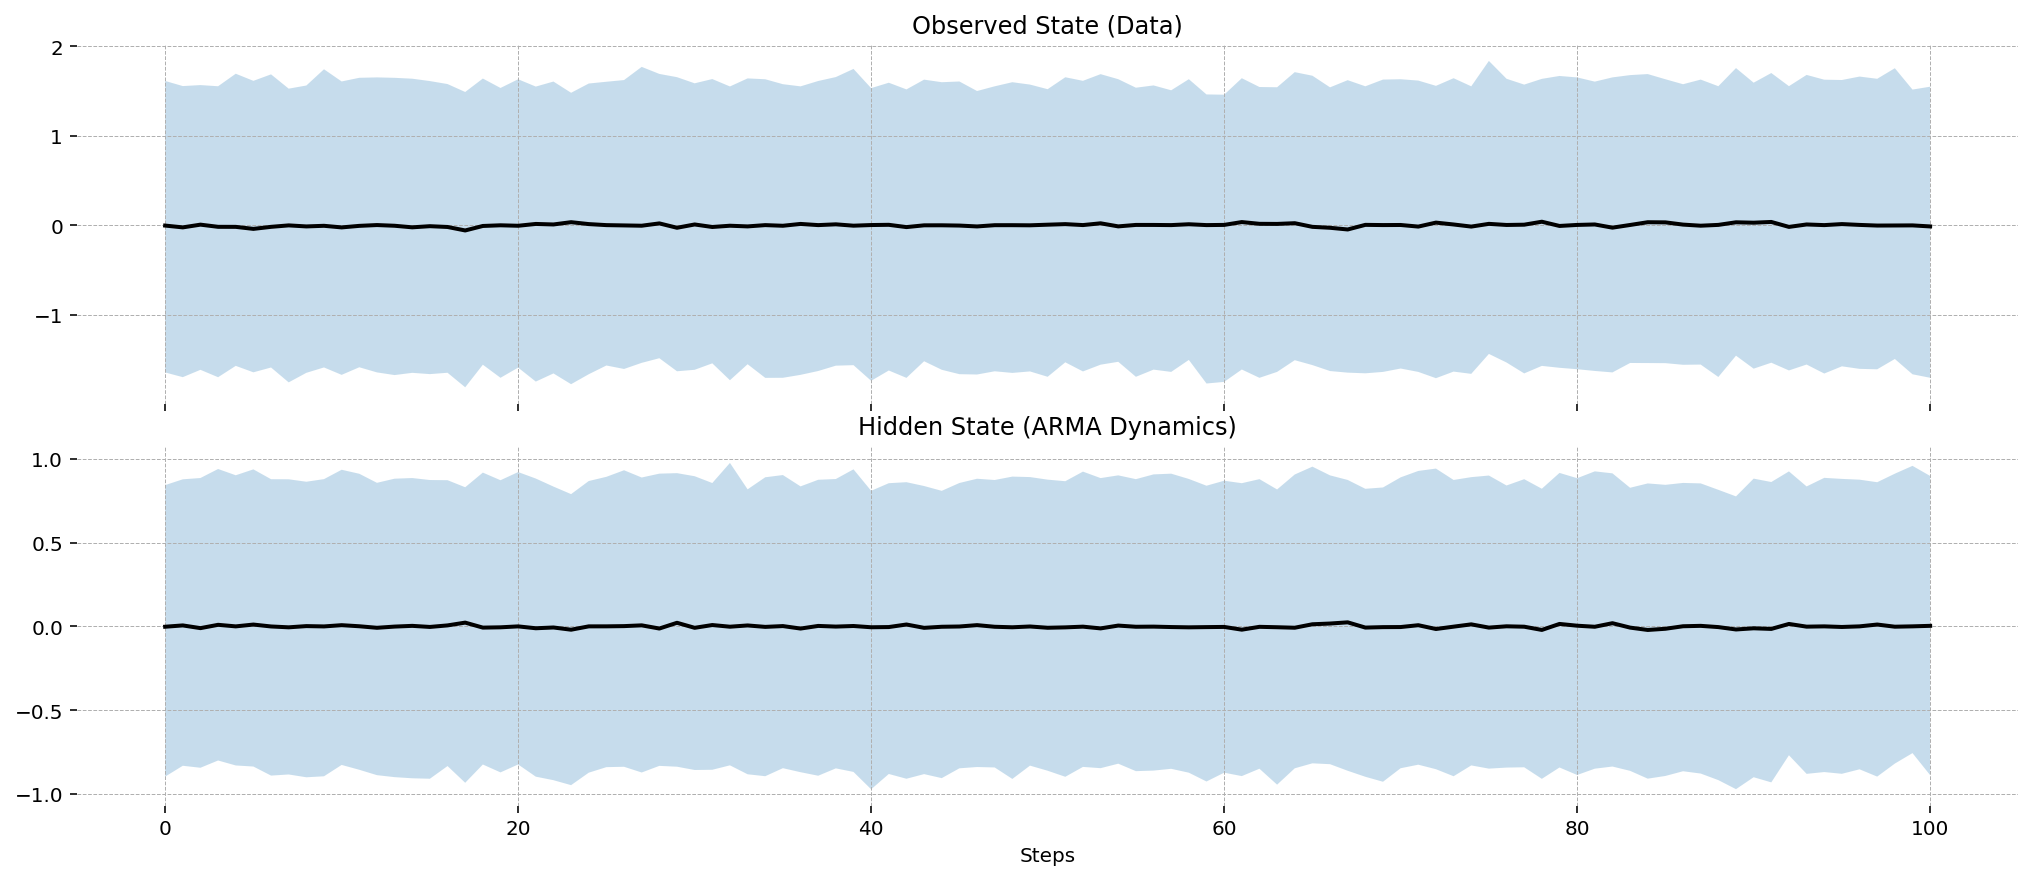

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6), dpi=144, sharex=True)
hdi = az.hdi(unconditional_post.to_dataset().posterior_latent)

for idx, (axis, name) in enumerate(
    zip(fig.axes, ["Observed State (Data)", "Hidden State (ARMA Dynamics)"])
):
    unconditional_draws.isel(state=idx).mean(dim="sample").posterior_latent.plot.line(
        x="time", ax=axis, color="k", lw=2, add_legend=False
    )
    axis.fill_between(hdi.coords["time"], *hdi.isel(state=idx).values.T, alpha=0.25)
    axis.set(title=name, xlabel="", ylabel="")

ax[-1].set_xlabel("Steps")
plt.show()

As a model check, we can compute the closed form steady state distribution of the state space system under the posterior and check whether the simulations are converging to it. The closed form mean and covariance matrix are:

$$\begin{aligned}
\mu^\star &= (I - T)^{-1} c \\
\Sigma^\star &= T \Sigma^\star T^T - T \Sigma^\star Z^T F^{-1} Z \Sigma^\star T^T + R Q R^T
\end{aligned}$$

The first equation assumes that $T$ is invertible, which means that the system needs to be stationary. These results thus don't apply to, say, a Gaussian Random Walk model. The second equation is a Discrete Matrix Riccati Equation. A `pytensor` solver is available, but is not JAX compatible.

In [22]:
with pm.Model(coords=ss_mod.coords):
    ss_mod._build_dummy_graph(idata)
    x0_pt, P0_pt, c_pt, d_pt, T_pt, Z_pt, R_pt, H_pt, Q_pt = ss_mod.unpack_statespace()

    mu_star = pm.Deterministic(
        "mu_star", pt.linalg.inv(pt.eye(ss_mod.k_states) - T_pt) @ c_pt, dims=["state"]
    )
    Sigma_star = pm.Deterministic(
        "Sigma_star",
        pt.linalg.solve_discrete_are(T_pt.T, Z_pt.T, R_pt @ Q_pt @ R_pt.T, H_pt),
        dims=["state", "state_aux"],
    )

    idata_steady = pm.sample_posterior_predictive(
        idata, var_names=["mu_star", "Sigma_star"], random_seed=1337
    )

Sampling: []


Output()

After 100 time steps, the mean and covariance of the simulated draws are close to the analytic posterior steady state.

In [23]:
final_draws = unconditional_draws.posterior_latent.isel(time=-1).values
steady_state = idata_steady.posterior_predictive.mean(dim=["chain", "draw"])
states = list(ss_mod.state_names)

steady_state_mean = pd.DataFrame(
    {
        "Simulated": final_draws.mean(axis=-1),
        "Analytic": steady_state.mu_star.values,
    },
    index=pd.Index(states, name="State"),
)
steady_state_mean

,Simulated,Analytic
State,,
data,-0.012835,0.0
state_1,0.003864,0.0


In [24]:
steady_state_cov = pd.concat(
    {
        "Simulated": pd.DataFrame(np.cov(final_draws), index=states, columns=states),
        "Analytic": pd.DataFrame(steady_state.Sigma_star.values, index=states, columns=states),
    },
    axis=1,
)
steady_state_cov

Simulated            Analytic          
             data   state_1      data   state_1
data     1.054267 -0.487987  0.864730 -0.482647
state_1 -0.487987  0.312615 -0.482647  0.306066

### Conditional

In [25]:
post_pred = ss_mod.sample_conditional_posterior(idata)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

Comparing the posterior outputs, you can see that only the Kalman predictions have posterior errors. This is because there is no measurement error in this model, nor unobserved shocks to the hidden states. In the context of the Kalman Filter, this has the effect of noiselessly encoding the data during the filter step (and the smoother is based on the filtered distribution).

In all three posterior predictive distributions, we can see that there is noise in the hidden state estimation. This amounts to estimation of the innovation series, scaled by the MA parameter $\theta$ (refer to the algebra above). This amounts to draws from a fixed Normal distribution in the filtered and predictive distributions, but more closely follows the data in the smoothed distribution, since this takes into account both past and future observations.

In [26]:
FILTER_COLORS = {"filtered": "tab:blue", "predicted": "tab:orange", "smoothed": "tab:green"}


def plot_conditional_posterior(post_pred, state_labels):
    fig, axes = plt.subplots(len(state_labels), 1, figsize=(14, 6), dpi=144, sharex=True)
    draws = az.extract(post_pred, "posterior_predictive")
    hdi_all = az.hdi(post_pred.to_dataset())

    for filter_output, color in FILTER_COLORS.items():
        variable = f"{filter_output}_posterior"
        hdi = hdi_all[variable]
        for idx, (axis, label) in enumerate(zip(axes, state_labels)):
            draws[variable].isel(state=idx).mean(dim="sample").plot.line(
                x="time",
                ax=axis,
                lw=2,
                add_legend=False,
                label=filter_output.title(),
                color=color,
            )
            axis.fill_between(
                hdi.coords["time"], *hdi.isel(state=idx).values.T, alpha=0.25, color=color
            )
            axis.set(title=label, xlabel="", ylabel="")

    axes[-1].set_xlabel("Date")
    axes[0].legend()

    return fig

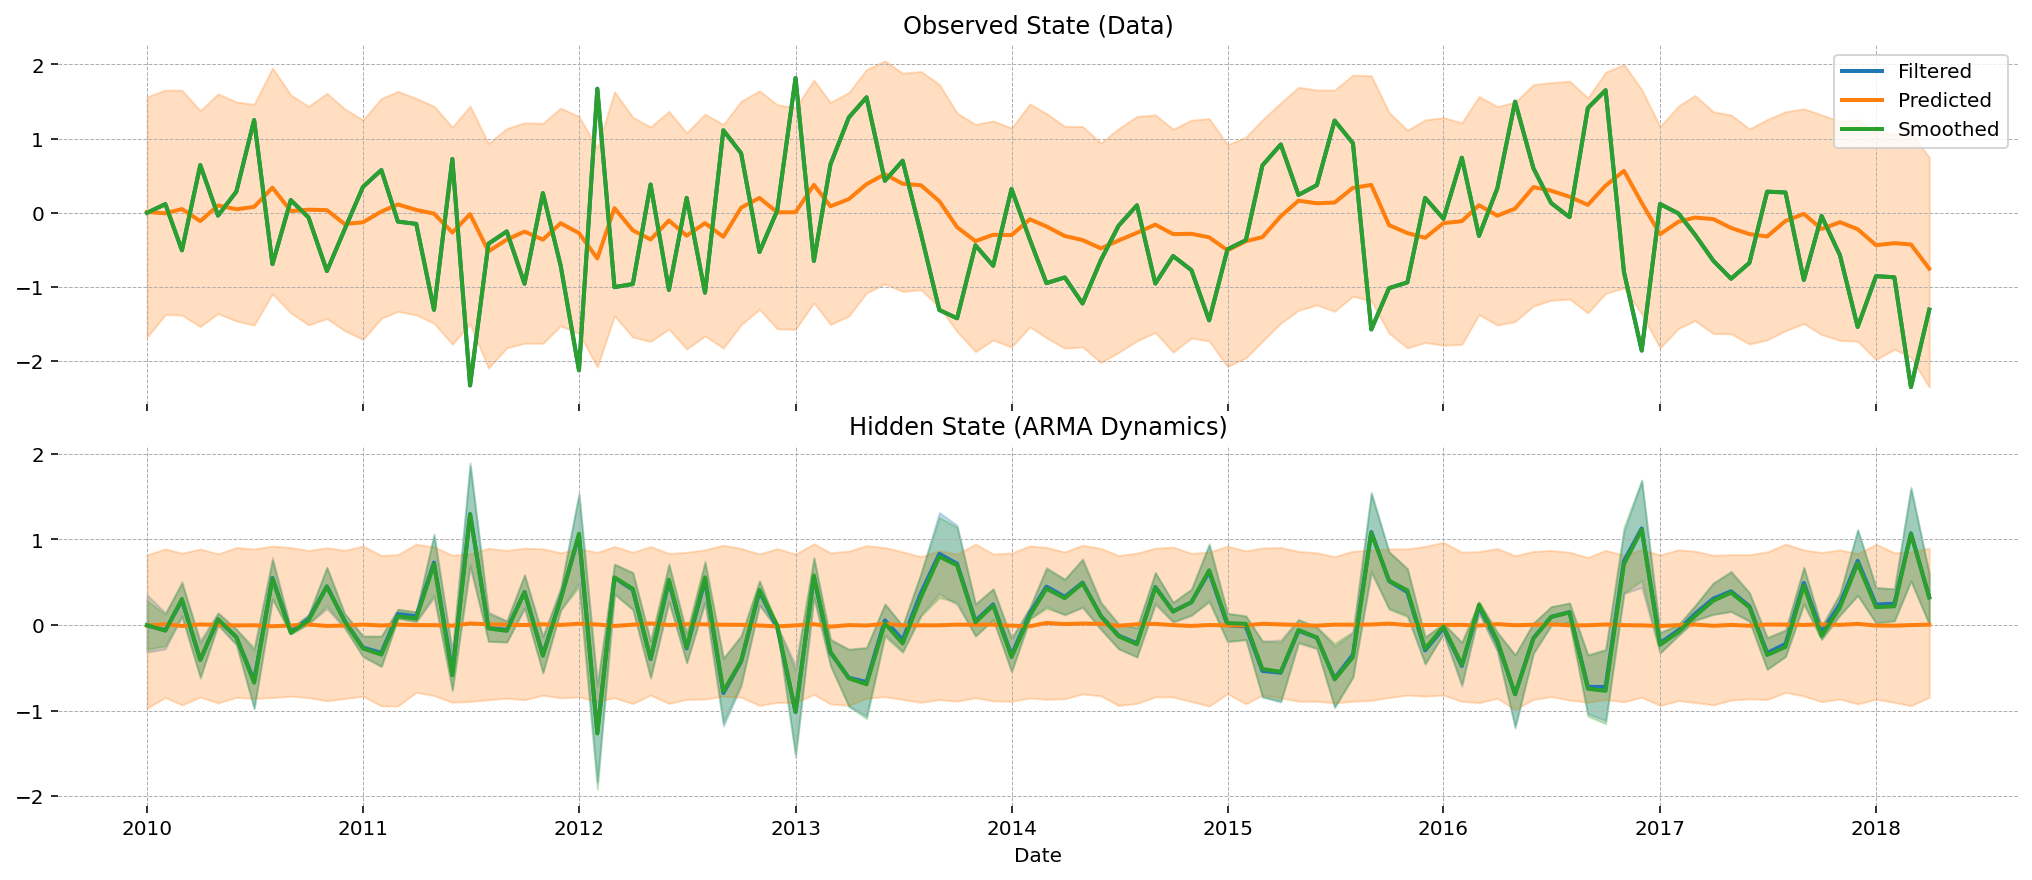

In [27]:
plot_conditional_posterior(
    post_pred, state_labels=["Observed State (Data)", "Hidden State (ARMA Dynamics)"]
)
plt.show()

## Predictions Compared

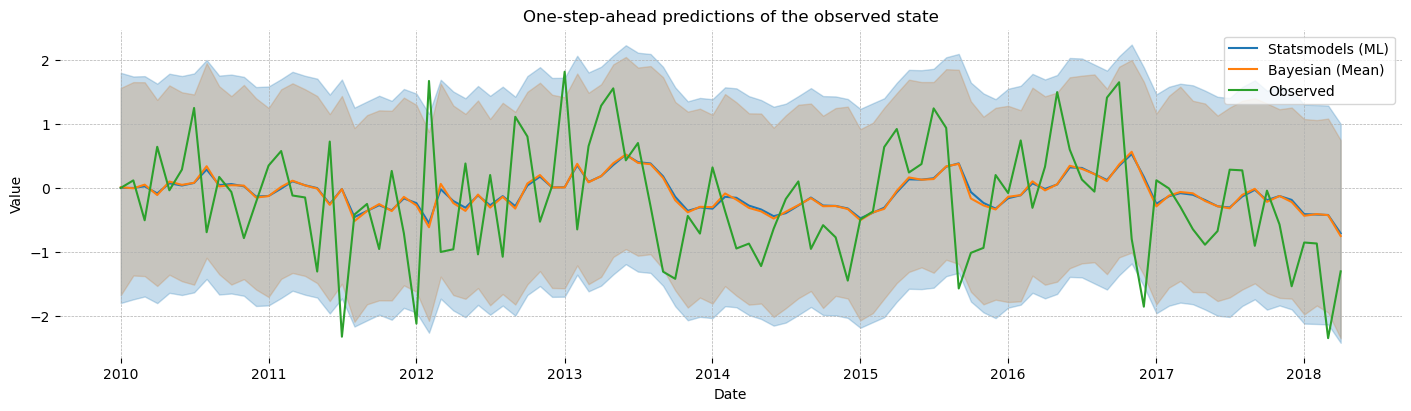

In [28]:
post = az.extract(post_pred, "posterior_predictive")
hdi = az.hdi(post_pred.to_dataset()).predicted_posterior

ml_mu = res.states.predicted[:-1, 0]
ml_var = res.states.predicted_cov.reshape(-1, 2, 2)[:-1, 0, 0]

fig, ax = plt.subplots(figsize=(14, 4), dpi=100)
ax.plot(df.index, ml_mu, label="Statsmodels (ML)")
post.mean(dim="sample").isel(state=0).predicted_posterior.plot.line(
    x="time", label="Bayesian (Mean)"
)
ax.fill_between(
    df.index,
    *hdi.isel(state=0).values.T,
    alpha=0.25,
    color="tab:orange",
)
ax.fill_between(
    df.index,
    ml_mu - 1.96 * np.sqrt(ml_var),
    ml_mu + 1.96 * np.sqrt(ml_var),
    alpha=0.25,
    color="tab:blue",
)
ax.plot(df.index, df.values, label="Observed")

ax.set(title="One-step-ahead predictions of the observed state", xlabel="Date", ylabel="Value")
ax.legend()
plt.show()

### Forecasting

Forecasting is also easy, just use the `forecast` method.

In [29]:
def plot_forecast(df, idata_forecast, title):
    fig, ax = plt.subplots(figsize=(14, 4), dpi=100)
    forecast = az.extract(idata_forecast, "posterior_predictive")
    hdi_forecast = az.hdi(idata_forecast.to_dataset()).forecast_observed

    ax.plot(df.index, df.values, label="Data")
    forecast.mean(dim="sample").forecast_observed.isel(observed_state=0).plot.line(
        x="time", ax=ax, label="Forecast", add_legend=False
    )
    ax.fill_between(
        forecast.coords["time"].values,
        *hdi_forecast.isel(observed_state=0).values.T,
        alpha=0.25,
        color="tab:orange",
        label="89% HDI",
    )

    ax.set(title=title, xlabel="Date", ylabel="Value")
    ax.legend()

    return fig

Sampling: [forecast_combined]


Output()

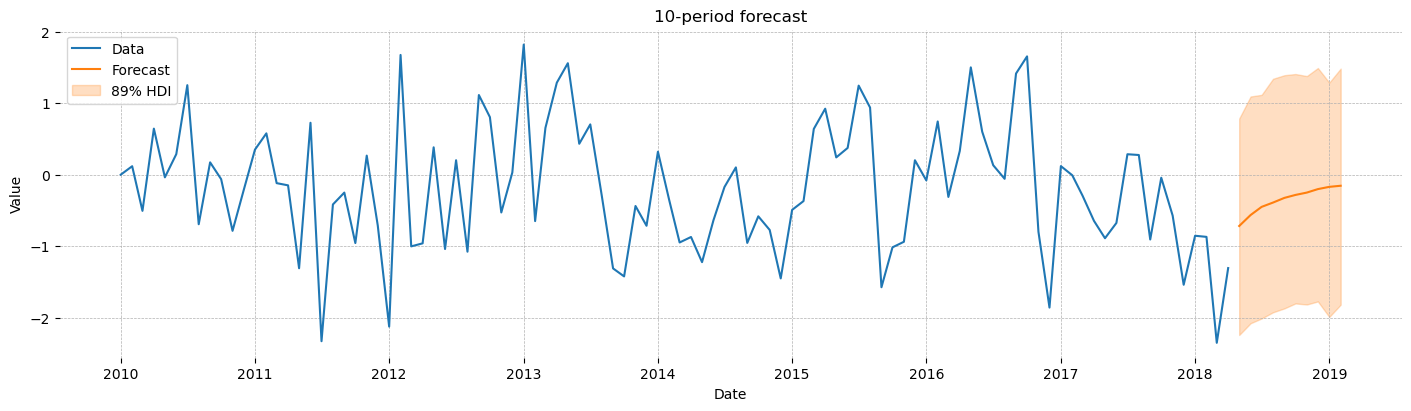

In [30]:
idata_forecast = ss_mod.forecast(idata, start=df.index[-1], periods=10)
plot_forecast(df, idata_forecast, title="10-period forecast")
plt.show()

### Porcupine Graph

A "porcupine graph" shows model forecasts at different periods in the time series. The name comes from the fact that forecast lines poke out from the data like porcupine quills. We make one for this data to show the flexibility of the forecast method.

This isn't a true porcupine graph though, because the "forecasts" for the in-sample period are generated using parameters fit on data from the future. It's just a demonstration of the forecast method.

In [31]:
forecast_idatas = []
for date in df.index[10::10]:
    with warnings.catch_warnings():
        # The PyMC warning about JAX shared variables fires once per forecast call.
        warnings.simplefilter("ignore")
        forecast_idatas.append(
            ss_mod.forecast(
                idata, start=date, periods=5, filter_output="smoothed", progressbar=False
            )
        )

Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


Sampling: [forecast_combined]


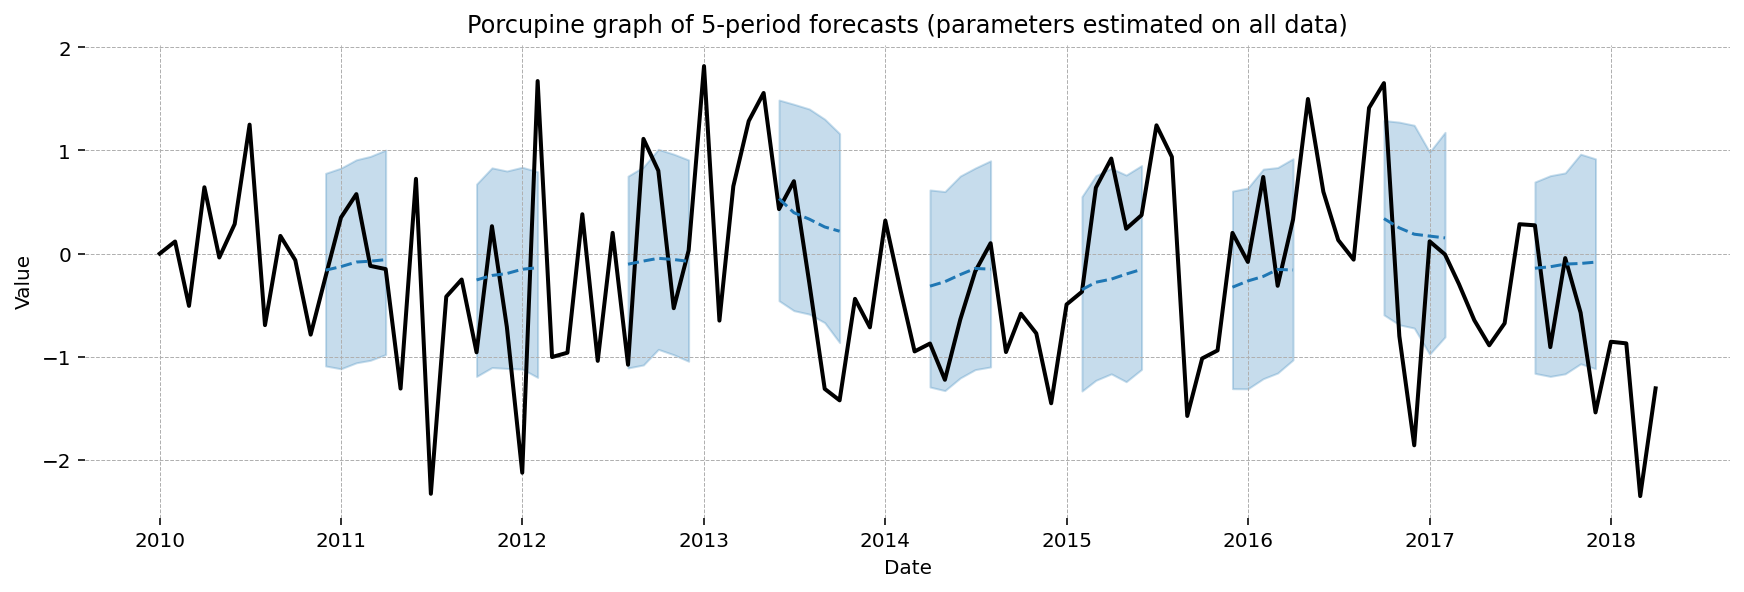

In [32]:
fig, ax = plt.subplots()
ax.plot(df.index, df.values, lw=2, c="k", label="Data")

for forecast_idata in forecast_idatas:
    forecast = az.extract(forecast_idata, "posterior_predictive")
    hdi_forecast = az.hdi(forecast_idata.to_dataset(), prob=0.69).forecast_observed

    mean = forecast.mean(dim="sample").forecast_observed.isel(observed_state=0)
    mean.plot.line(x="time", ax=ax, color="tab:blue", ls="--")
    ax.fill_between(
        hdi_forecast.coords["time"].values,
        *hdi_forecast.isel(observed_state=0).values.T,
        alpha=0.25,
        color="tab:blue",
    )

ax.set(
    title="Porcupine graph of 5-period forecasts (parameters estimated on all data)",
    xlabel="Date",
    ylabel="Value",
)
plt.show()

### Impulse Response Function

In [33]:
def plot_irf(irf, title, ax=None, add_legend=True):
    if ax is None:
        _, ax = plt.subplots()

    mean = irf.irf.mean(dim=["chain", "draw"])
    hdi_50 = az.hdi(irf.to_dataset(), 0.5).irf
    hdi = az.hdi(irf.to_dataset()).irf

    x_time = irf.coords["time"]

    ax.plot(x_time, mean, color="k", label="Mean")
    ax.fill_between(x_time, *hdi.values.T, color="tab:blue", alpha=0.25, label="89% HDI")
    ax.fill_between(x_time, *hdi_50.values.T, color="tab:blue", alpha=0.5, label="50% HDI")
    ax.set(title=title, xlabel="Steps after shock", ylabel="Response")

    if add_legend:
        ax.legend()

    return ax

#### Via posterior sampling of the shock matrix

Sampling: [initial_shock]


Output()

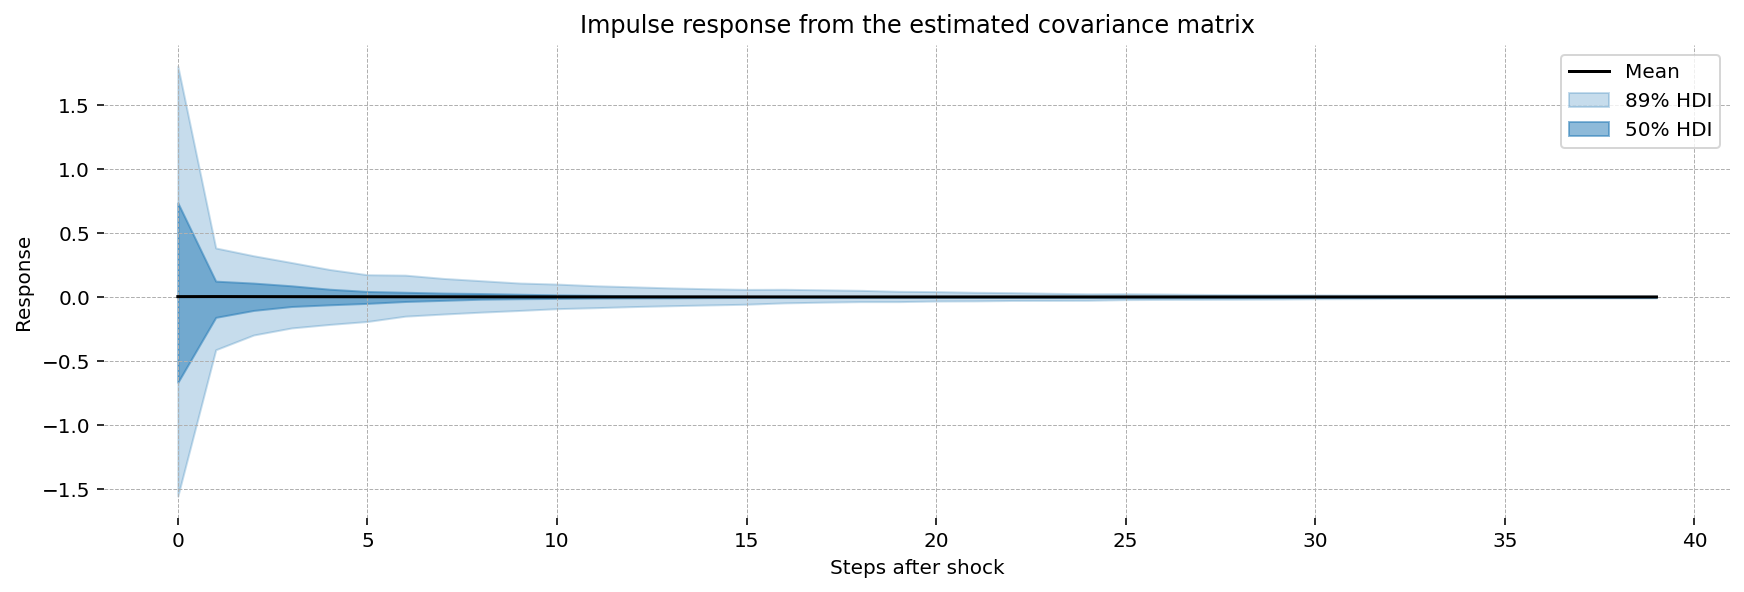

In [34]:
steps = 40
irf = ss_mod.impulse_response_function(idata, n_steps=steps, orthogonalize_shocks=True)
plot_irf(irf.isel(state=0), title="Impulse response from the estimated covariance matrix")
plt.show()

#### Create a custom shock scenario

Sampling: []


Output()

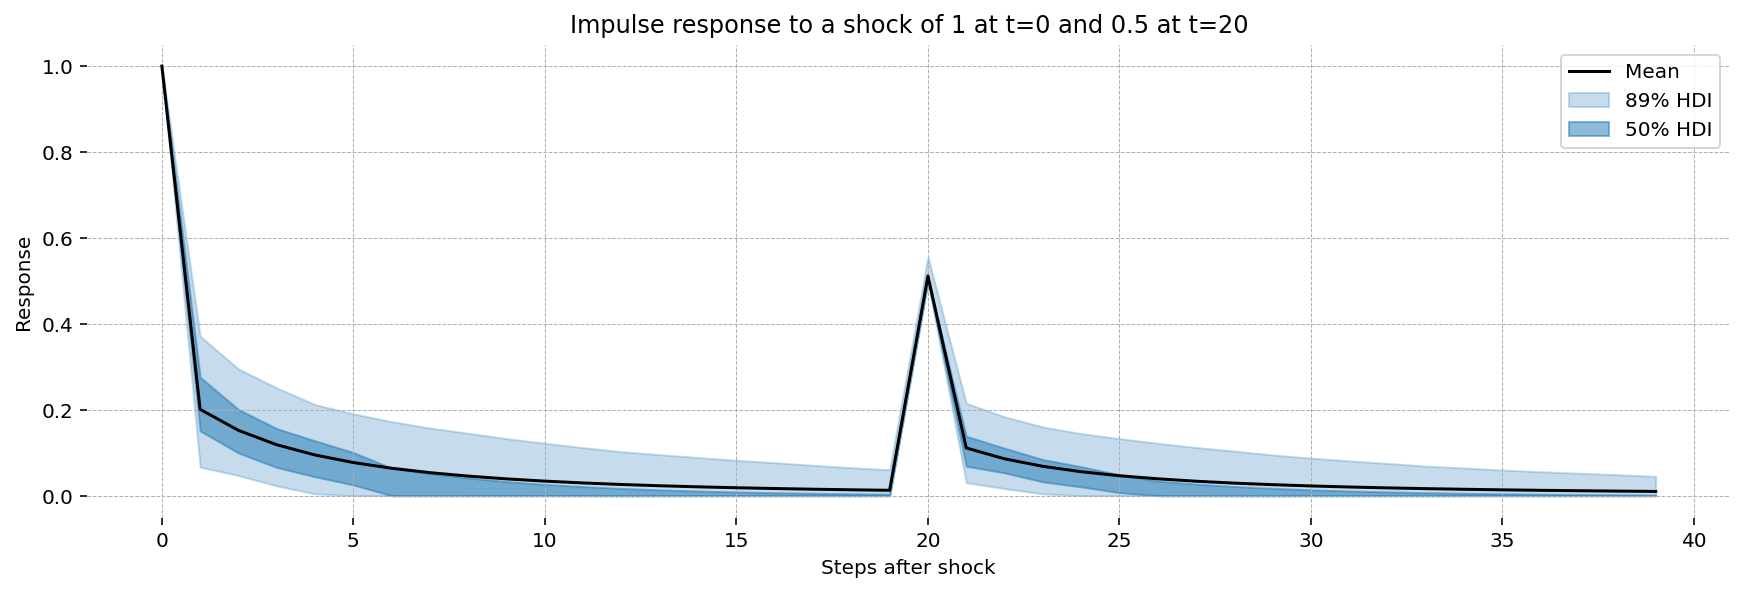

In [35]:
shock_trajectory = np.zeros((steps, ss_mod.k_posdef))
shock_trajectory[0] = 1
shock_trajectory[20] = 0.5

irf = ss_mod.impulse_response_function(idata, shock_trajectory=shock_trajectory)
plot_irf(irf.isel(state=0), title="Impulse response to a shock of 1 at t=0 and 0.5 at t=20")
plt.show()

## Interpretable ARMA

In addition to the usual formulation, there's also an "interpretable" formulation of the ARMA model. It has significantly more states, which makes it a bad choice if speed is critical. But for a smallish model on smallish data, it lets us directly recover the innovation trajectory.

We can also add measurement error to the model, in case we have some reason to doubt the data.

In [36]:
ss_mod = pmss.BayesianSARIMAX(
    order=(1, 0, 1),
    state_structure="interpretable",
    measurement_error=True,
    verbose=True,
)

                Model Requirements                 
                                                   
  Variable      Shape   Constraints    Dimensions  
 ───────────────────────────────────────────────── 
  ar_params     (1,)                  ('lag_ar',)  
  ma_params     (1,)                  ('lag_ma',)  
  sigma_state   ()      Positive             None  
  sigma_obs     ()      Positive             None  
                                                   
These parameters should be assigned priors inside a
        PyMC model block before calling the        
          build_statespace_graph method.           

In [37]:
with pm.Model(coords=ss_mod.coords) as interpretable_model:
    state_sigmas = pm.Gamma(
        "sigma_state", alpha=2.0, beta=1.0, dims=ss_mod.param_dims.get("sigma_state")
    )
    obs_sigmas = pm.Gamma("sigma_obs", alpha=2.0, beta=1.0, dims=ss_mod.param_dims.get("sigma_obs"))
    rho = pm.TruncatedNormal(
        "ar_params",
        mu=0.0,
        sigma=0.5,
        lower=-1.0,
        upper=1.0,
        dims=ss_mod.param_dims.get("ar_params"),
    )
    theta = pm.Normal("ma_params", mu=0.0, sigma=0.5, dims=ss_mod.param_dims.get("ma_params"))
    ss_mod.build_statespace_graph(df)

    idata = pm.sample(**sample_kwargs())

NUTS[nutpie]: [sigma_state, sigma_obs, ar_params, ma_params]


Output()

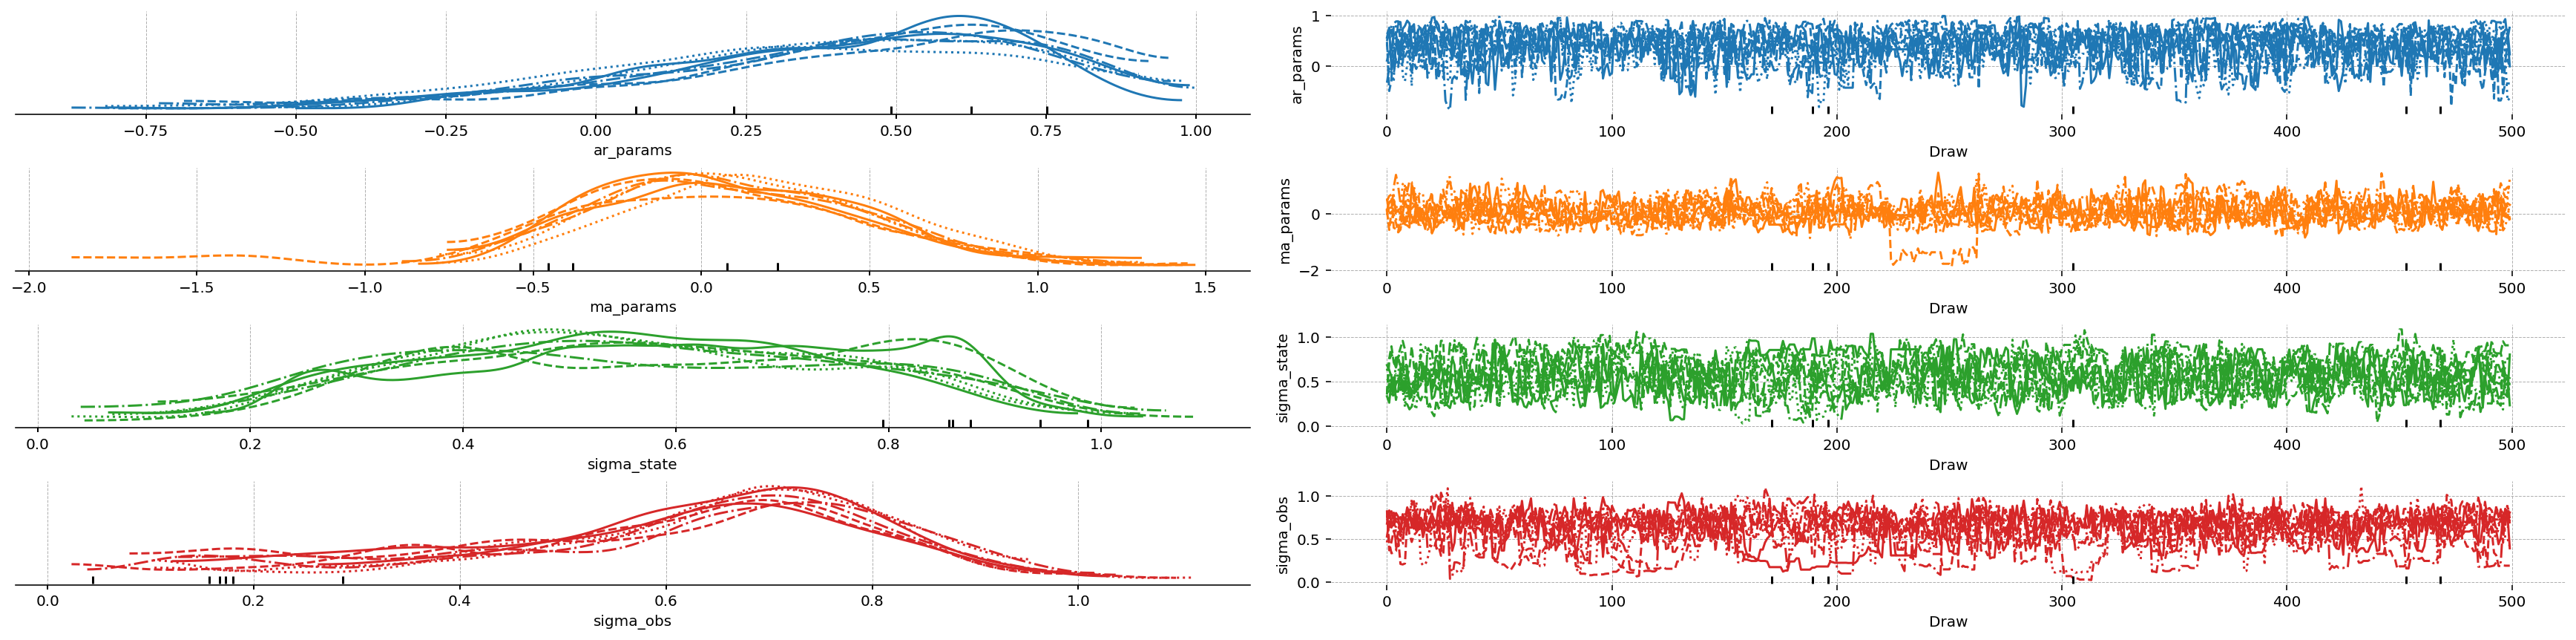

In [38]:
az.plot_trace_dist(idata, var_names=list(ss_mod.param_names));

In [39]:
post_pred = ss_mod.sample_conditional_posterior(idata)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

We can see that the smoother output for the observed Data variable is no longer a perfect fit and has some posterior uncertainty resulting from measurement error. The hidden state is now the exact innovation series, unscaled by theta or lagged, which makes it easier to interpret, as advertised.

Also, since we are trusting the data less, the Smoother learns a lot less about the hidden state relative to the Filter -- the two are very similar.

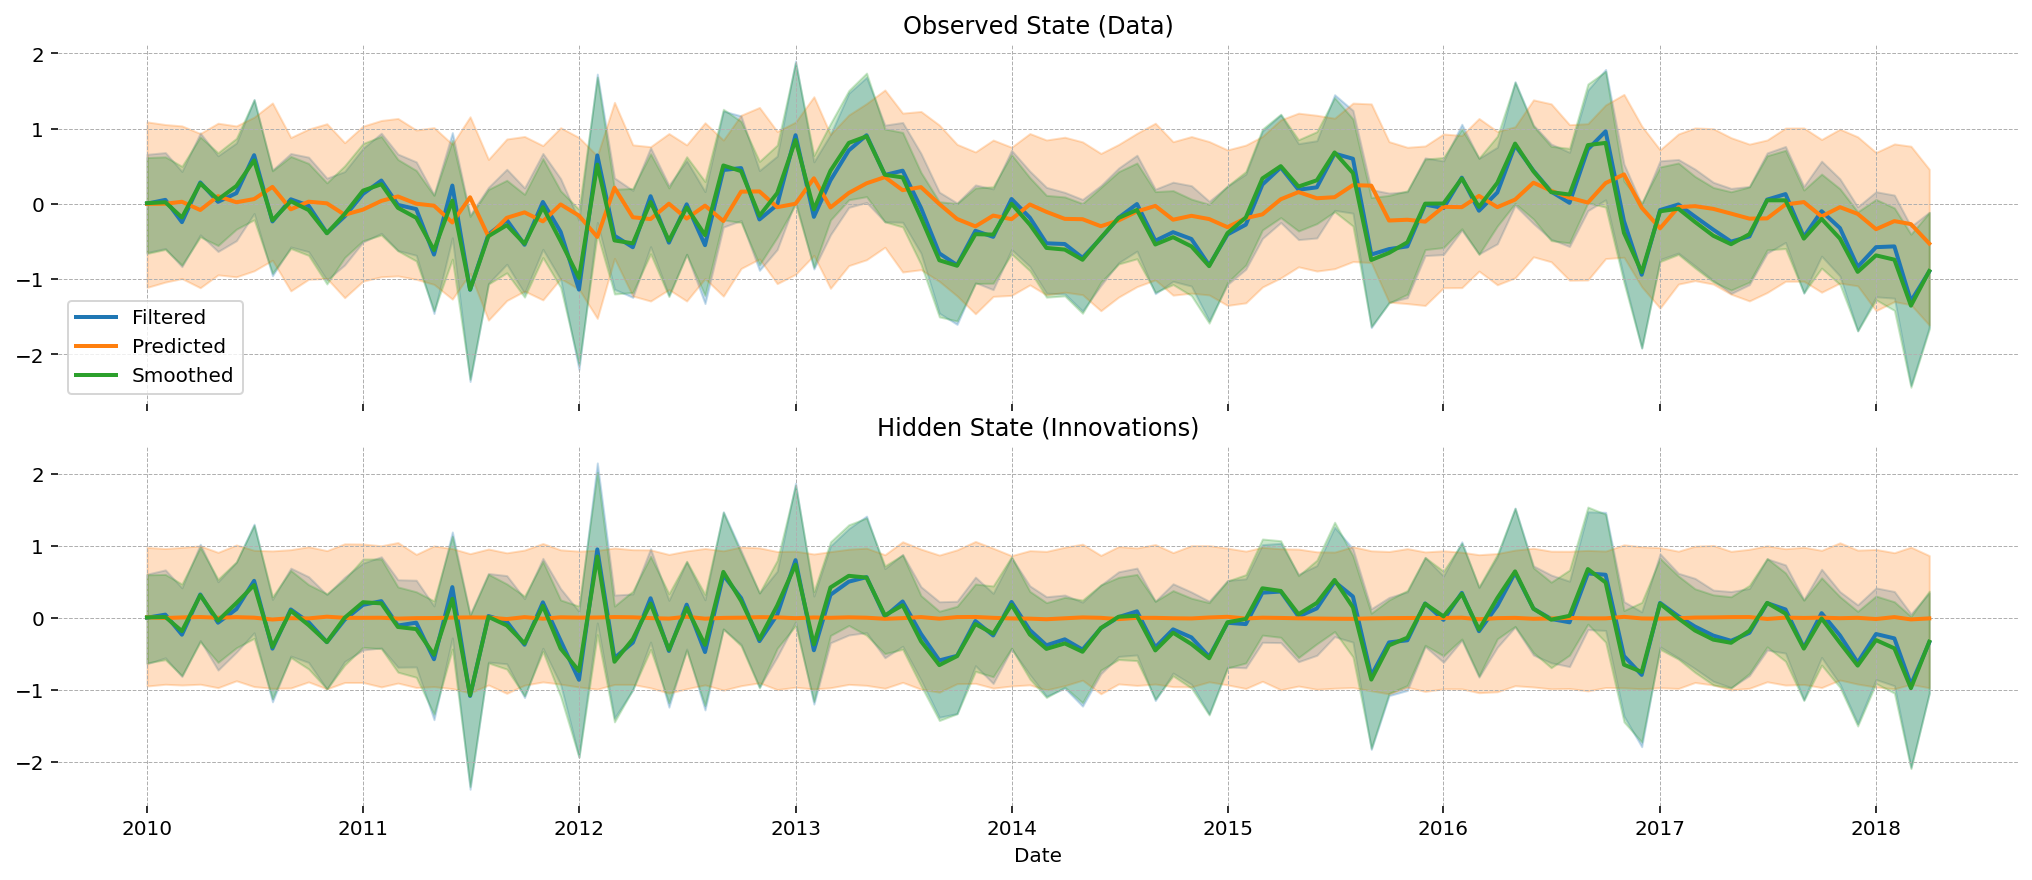

In [40]:
plot_conditional_posterior(
    post_pred, state_labels=["Observed State (Data)", "Hidden State (Innovations)"]
)
plt.show()

Use an IRF to illustrate that the innovations state really is just a record of the shocks

Sampling: []


Output()

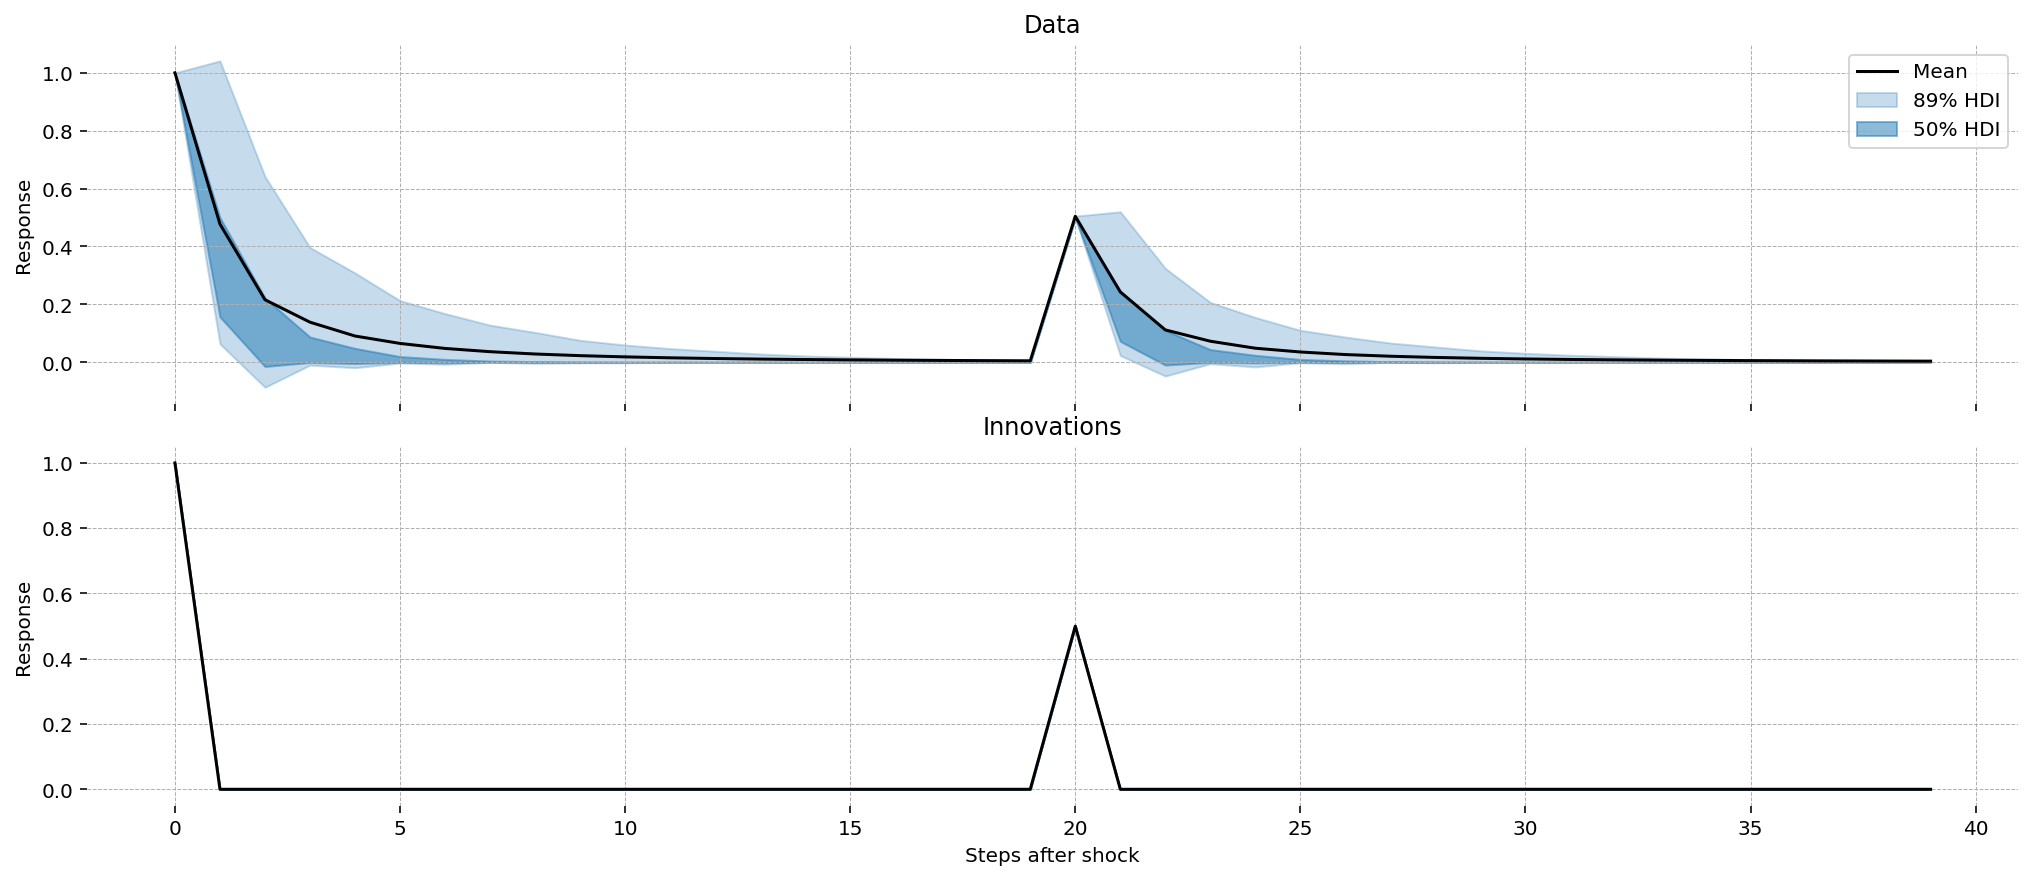

In [41]:
irf = ss_mod.impulse_response_function(idata, shock_trajectory=shock_trajectory)

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_irf(irf.sel(state="data"), title="Data", ax=ax[0])
plot_irf(irf.sel(state="innovations"), title="Innovations", ax=ax[1], add_legend=False)
ax[0].set_xlabel("")
plt.show()

## Seasonal Terms and Differences

Next, consider the airline passenger dataset. This dataset is interesting for several reasons. It has a non-stationary trend, and exhibits a strong seasonal pattern.

In [42]:
airpass = pd.read_csv(
    "../tests/statespace/_data/airpass.csv",
    parse_dates=True,
    date_format="%Y %b",
    index_col=0,
    dtype={"value": float},
).rename(columns={"value": "passengers"})
airpass.index.freq = airpass.index.inferred_freq

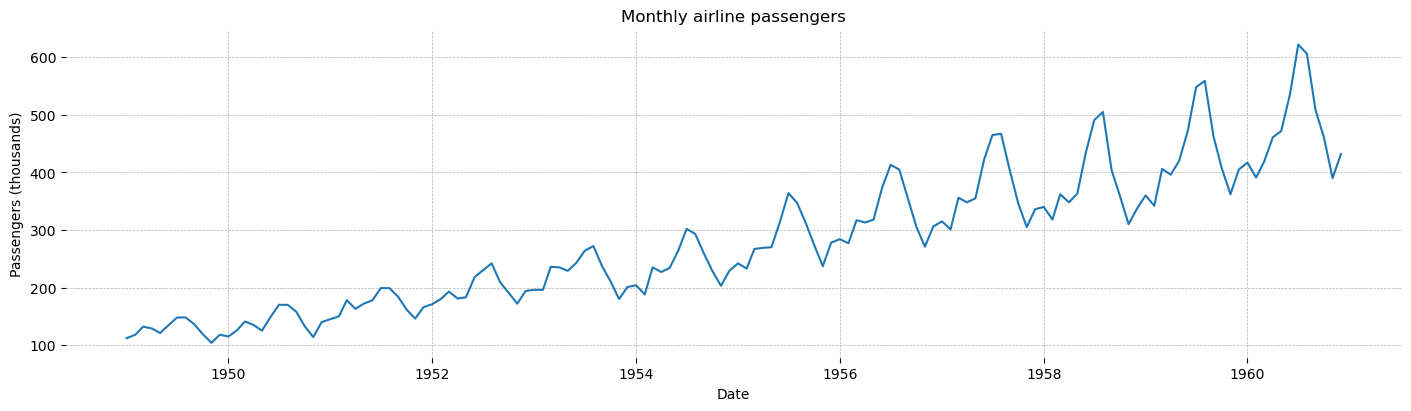

In [43]:
fig, ax = plt.subplots(figsize=(14, 4), dpi=100)
ax.plot(airpass.index, airpass["passengers"])
ax.set(title="Monthly airline passengers", xlabel="Date", ylabel="Passengers (thousands)")
plt.show()

SARIMA models require stationary data to be applied. This data is actually non-stationary in two ways. First, there is the trend. This can be handled via differencing. In many packages, differencing the data will force you to drop datapoints, but `statespace.BayesianSARIMA` can do the differencing inside the state space automatically, without losing any data.

The second source of non-stationarity is the growing autocovariance. It is clear that the size of the seasonal pattern is increasing over time, which is a tell-tale sign of a multiplicative timeseries, wherein the level of the series gets into the variance. Unfortunately, linear state space models can only handle linear models. So we will need to convert the multiplicative errors to linear errors by taking logs of the data. This cannot be done inside the model, and needs to be done by hand.

Let's take a look at what the log differences look like. This is just for illustration -- as noted, we don't actually need to difference by hand

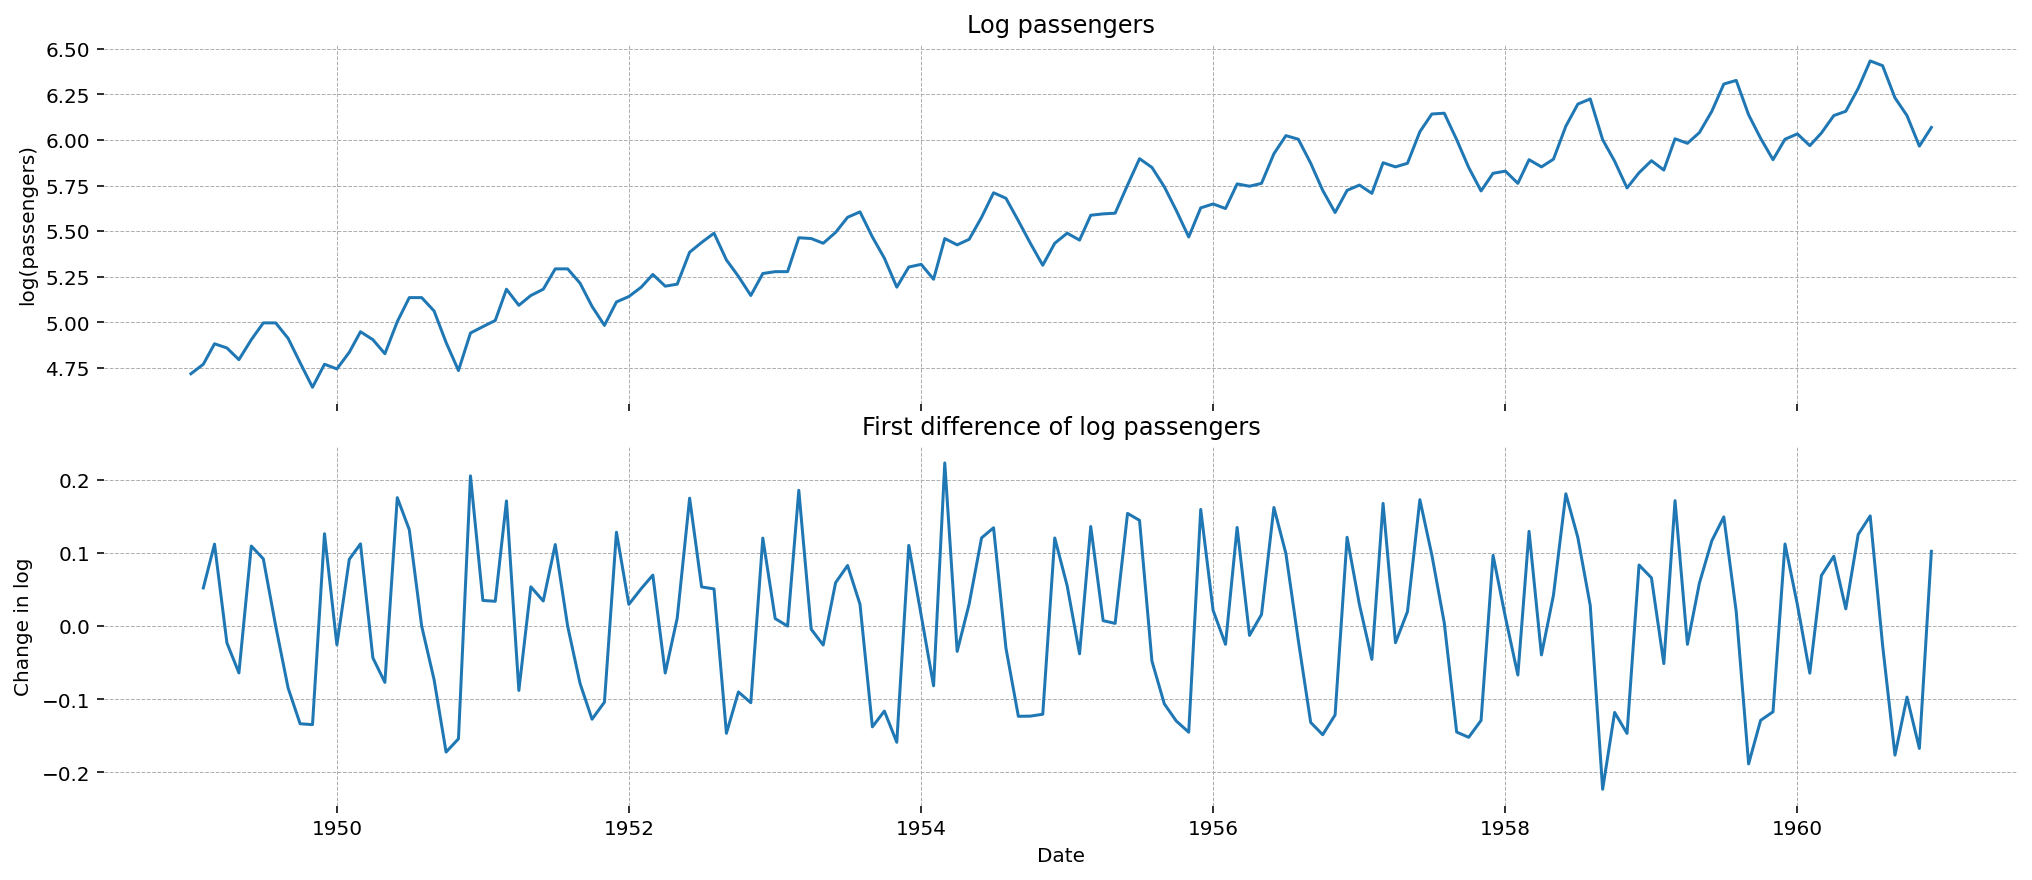

In [44]:
log_airpass = airpass.apply(np.log)

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax[0].plot(log_airpass.index, log_airpass["passengers"])
ax[0].set(title="Log passengers", ylabel="log(passengers)")

ax[1].plot(log_airpass.index, log_airpass["passengers"].diff())
ax[1].set(title="First difference of log passengers", xlabel="Date", ylabel="Change in log")
plt.show()

This looks stationary. There is no longer any upward trend, and the seasonal pattern looks stable over time. We could formalize the finding with an ADF or KPSS test, but we'll just go with the eyeball test.

Next we need to choose a seasonal order. It's annual data, so 12 seems reasonable. For the ARIMA order, we will use (2, 1, 2), and for the seasonal order, (2, 0, 2, 12).

In [45]:
ss_mod = pmss.BayesianSARIMAX(
    order=(2, 1, 2),
    seasonal_order=(2, 0, 2, 12),
    verbose=True,
    stationary_initialization=False,
)

                                Model Requirements                                 
                                                                                   
  Variable             Shape      Constraints                          Dimensions  
 ───────────────────────────────────────────────────────────────────────────────── 
  x0                   (28,)                                           ('state',)  
  P0                   (28, 28)   Positive Semi-definite   ('state', 'state_aux')  
  ar_params            (2,)                                           ('lag_ar',)  
  ma_params            (2,)                                           ('lag_ma',)  
  seasonal_ar_params   (2,)                                  ('seasonal_lag_ar',)  
  seasonal_ma_params   (2,)                                  ('seasonal_lag_ma',)  
  sigma_state          ()         Positive                                   None  
                                                                                   
These parameters should be assigned priors inside a PyMC model block before calling
                        the build_statespace_graph method.                         

In [46]:
with pm.Model(coords=ss_mod.coords) as sarima_model:
    # State 0 is associated with the observed data, and has a non-zero initial state, because the
    # data has a non-zero intercept.
    intercept = pm.Normal("intercept", mu=4.5, sigma=1, shape=(1,))
    x0 = pm.Deterministic(
        "x0", pt.concatenate([intercept, pt.zeros(ss_mod.k_states - 1)]), dims=["state"]
    )

    # Give state 0 its own sigma for the initial covariance; the stationary states share a single
    # sigma.
    sigma_P0 = pm.Gamma("sigma_P0", alpha=2, beta=10, shape=(2,))
    P0 = pt.eye(ss_mod.k_states) * sigma_P0[1]
    P0 = pt.set_subtensor(P0[0, 0], sigma_P0[0])
    P0 = pm.Deterministic("P0", P0, dims=["state", "state_aux"])

    ar_params = pm.Normal("ar_params", mu=0.0, sigma=0.5, dims=ss_mod.param_dims.get("ar_params"))
    seasonal_ar_params = pm.Normal(
        "seasonal_ar_params", mu=0.0, sigma=0.5, dims=ss_mod.param_dims.get("seasonal_ar_params")
    )

    ma_params = pm.Normal("ma_params", mu=0.0, sigma=0.5, dims=ss_mod.param_dims.get("ma_params"))
    seasonal_ma_params = pm.Normal(
        "seasonal_ma_params", mu=0.0, sigma=0.5, dims=ss_mod.param_dims.get("seasonal_ma_params")
    )

    state_sigmas = pm.Gamma(
        "sigma_state", alpha=2, beta=1.0, dims=ss_mod.param_dims.get("sigma_state")
    )

    # Remember to log the data by hand
    ss_mod.build_statespace_graph(log_airpass)

    idata = pm.sample(**sample_kwargs())

NUTS[nutpie]: [intercept, sigma_P0, ar_params, seasonal_ar_params, ma_params, seasonal_ma_params, sigma_state]


Output()

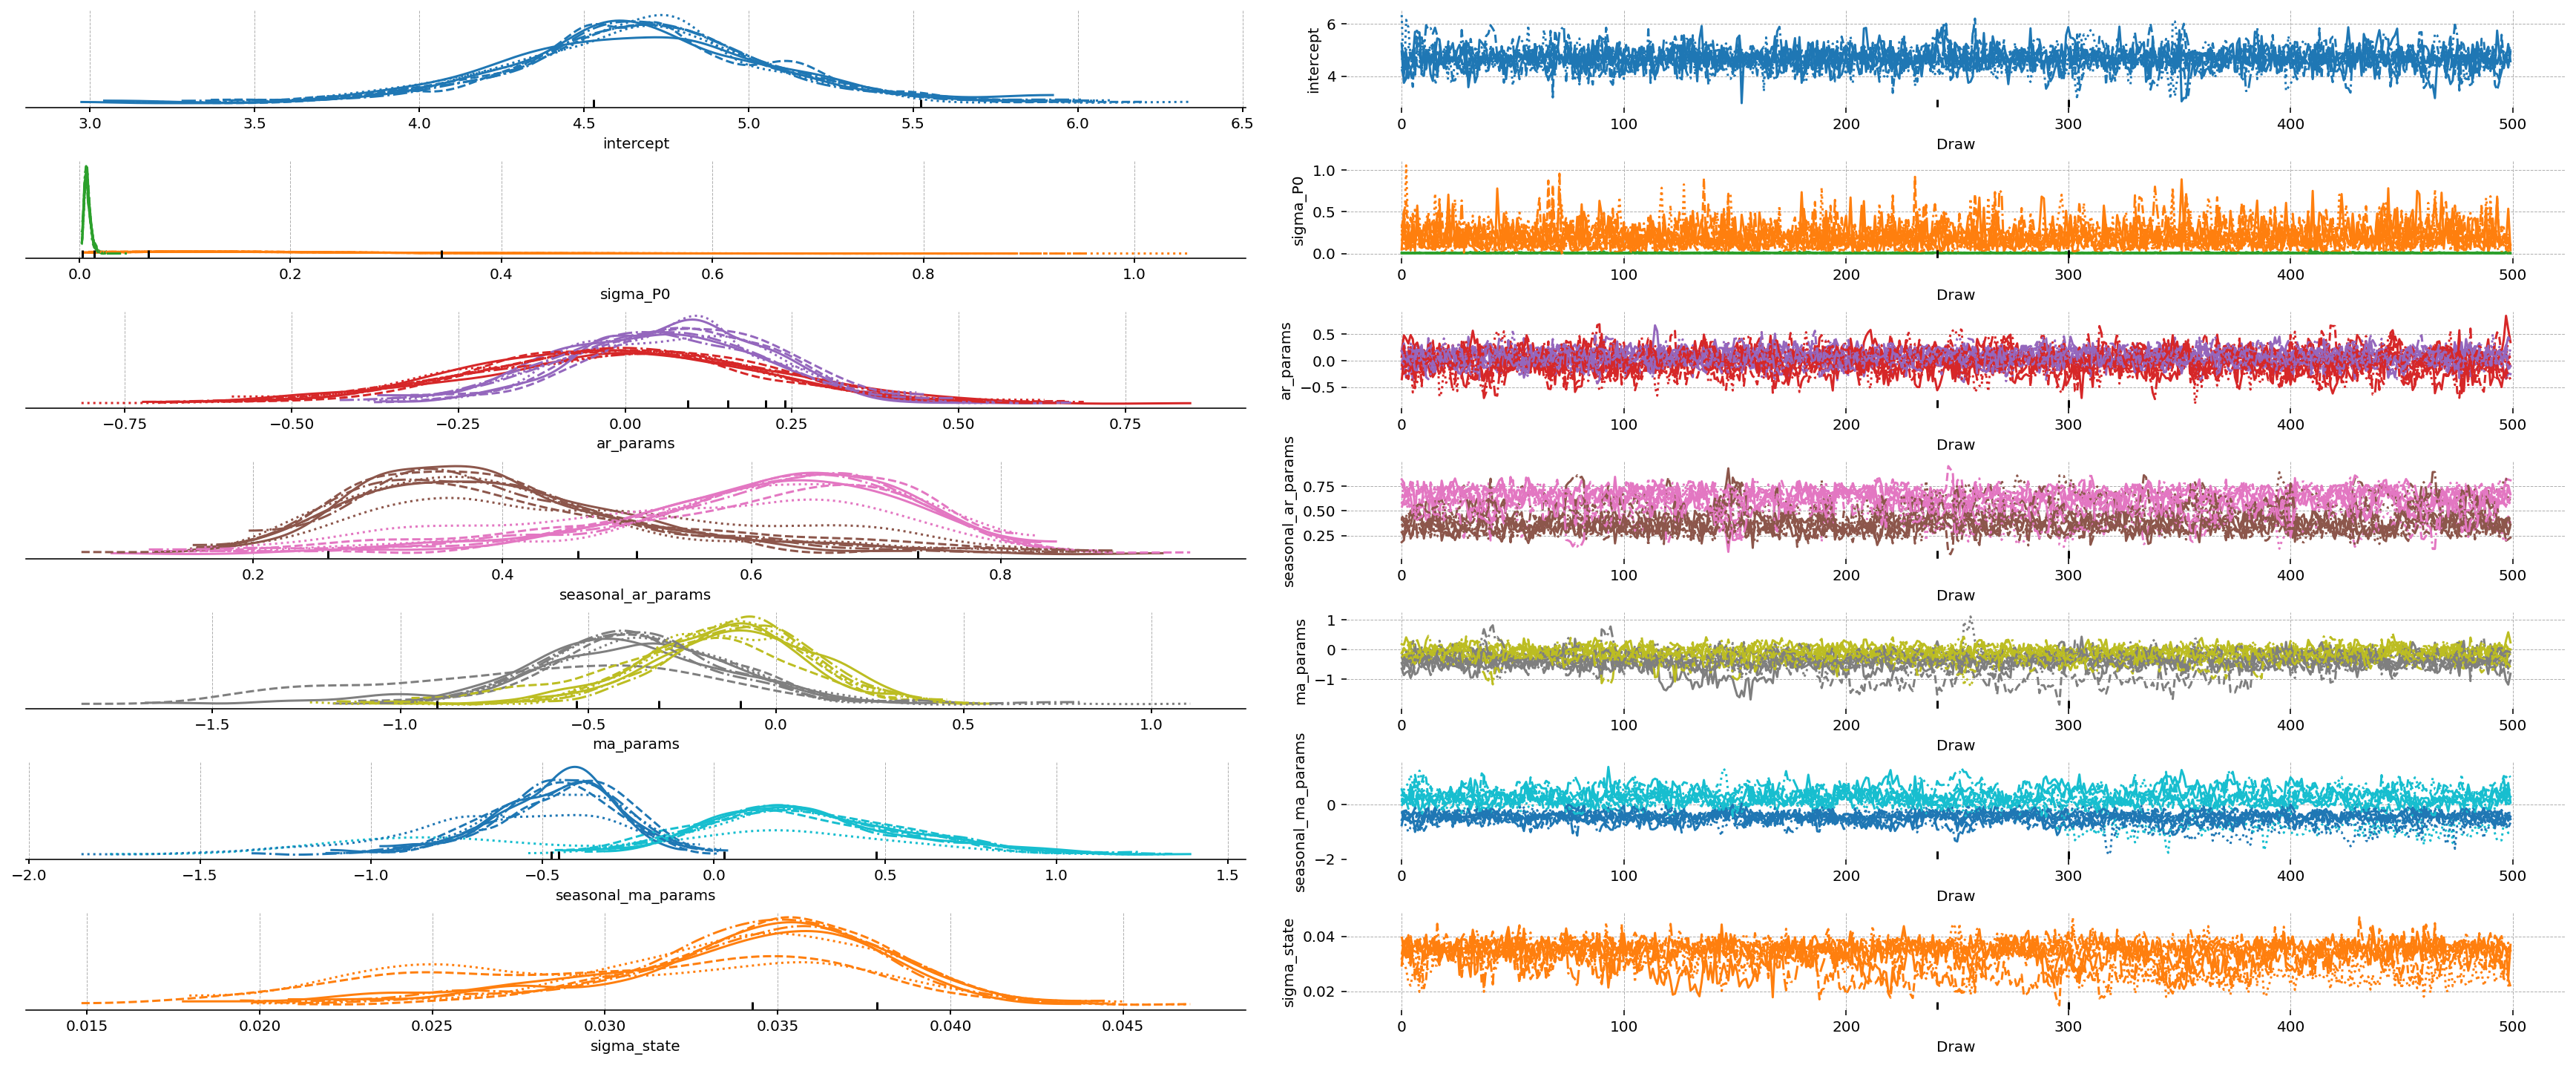

In [47]:
az.plot_trace_dist(idata, var_names=[rv.name for rv in sarima_model.basic_RVs[:-1]]);

#### Conditional Posterior

In [48]:
post_pred = ss_mod.sample_conditional_posterior(idata)

Sampling: [filtered_posterior, filtered_posterior_observed, predicted_posterior, predicted_posterior_observed, smoothed_posterior, smoothed_posterior_observed]


Output()

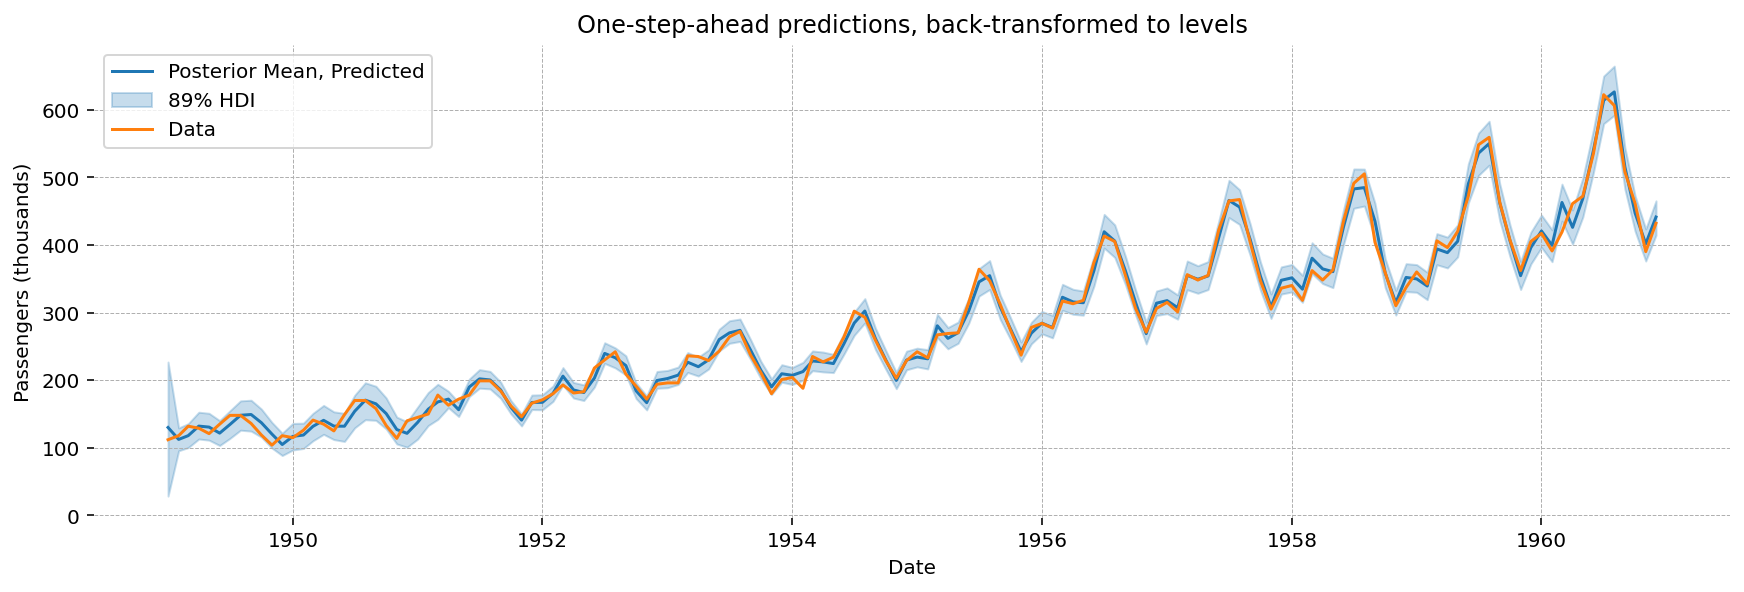

In [49]:
post = az.extract(post_pred, "posterior_predictive").map(np.exp)
hdi = az.hdi(post_pred.to_dataset().map(np.exp))["predicted_posterior_observed"]

fig, ax = plt.subplots()
post["predicted_posterior_observed"].isel(observed_state=0).mean(dim="sample").plot.line(
    x="time", ax=ax, add_legend=False, label="Posterior Mean, Predicted"
)
ax.fill_between(
    hdi.coords["time"],
    *hdi.isel(observed_state=0).values.T,
    alpha=0.25,
    color="tab:blue",
    label="89% HDI",
)
ax.plot(airpass.index, airpass.values, label="Data")

ax.set(
    title="One-step-ahead predictions, back-transformed to levels",
    xlabel="Date",
    ylabel="Passengers (thousands)",
)
ax.legend()
plt.show()

#### Forecasts

In [50]:
forecast_idata = ss_mod.forecast(idata, start=airpass.index[-1], periods=20)

Sampling: [forecast_combined]


Output()

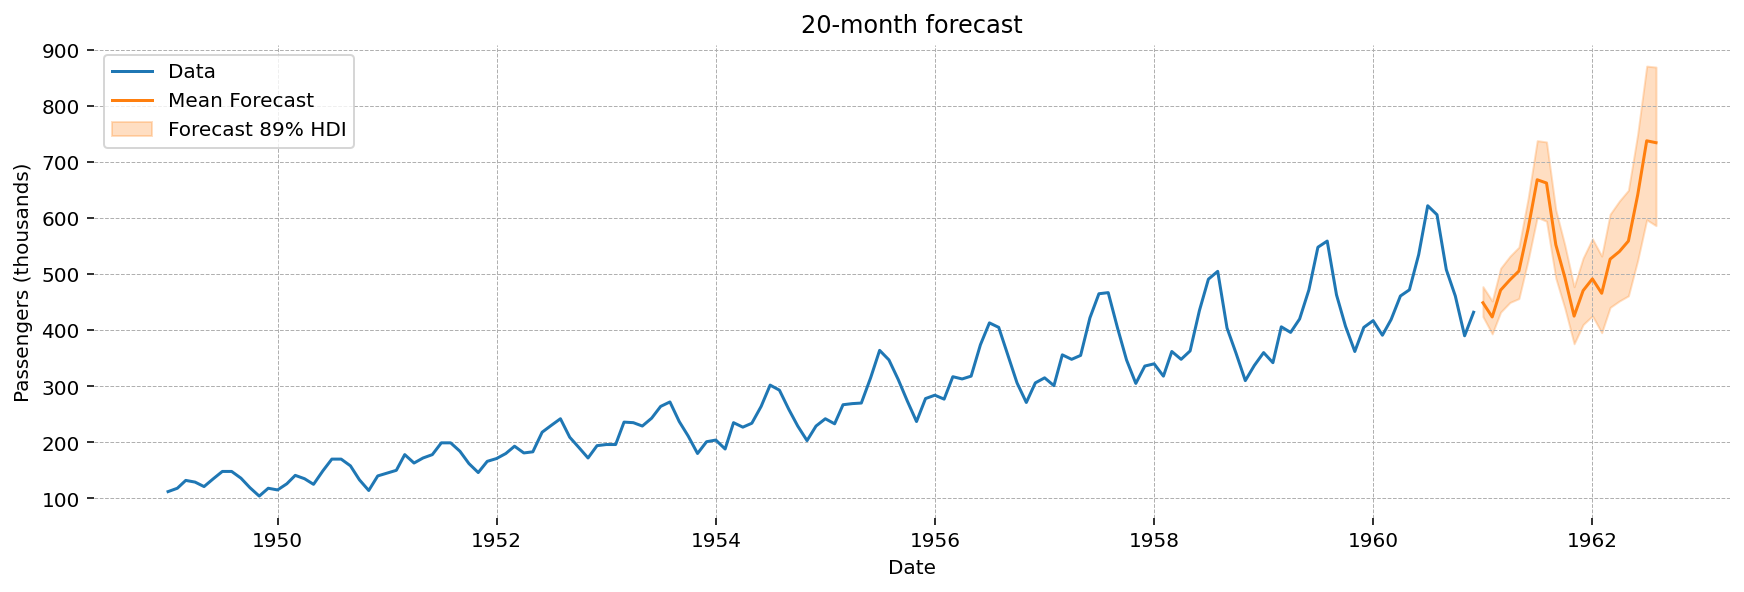

In [51]:
forecast_hdi = az.hdi(forecast_idata.to_dataset().map(np.exp)).forecast_observed.isel(
    observed_state=0
)
forecast_mu = forecast_idata.to_dataset().map(np.exp).forecast_observed.mean(dim=["chain", "draw"])

fig, ax = plt.subplots()
ax.plot(airpass.index, airpass.values, label="Data")
ax.plot(forecast_mu.coords["time"], forecast_mu, label="Mean Forecast")
ax.fill_between(
    forecast_mu.coords["time"],
    *forecast_hdi.values.T,
    label="Forecast 89% HDI",
    color="tab:orange",
    alpha=0.25,
)

ax.set(title="20-month forecast", xlabel="Date", ylabel="Passengers (thousands)")
ax.legend()
plt.show()